In [ ]:

import warnings
warnings.filterwarnings("ignore")
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [ ]:
DATE_COL = "Date"
TARGET_COL = "target_RV_gk"
REALIZED_COL = "RV_gk"

FILE_PATH = None
FILE_PATH = "/content/result_hope_8_march.xlsx"

TOP_N_TARGET_CORR = 25
TOP_N_HEATMAP = 25
HIGH_CORR_THRESHOLD = 0.85
FIGSIZE_WIDE = (16, 7)
FIGSIZE_HEATMAP = (14, 12)

TRAIN_END = None
VAL_END = None


In [ ]:
def load_table(file_path):
    if file_path is None:
        raise ValueError("FILE_PATH is None and dataframe df was not found in memory.")
    ext = os.path.splitext(file_path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)
    if ext in [".csv", ".txt"]:
        try:
            return pd.read_csv(file_path)
        except Exception:
            return pd.read_csv(file_path, sep=";")
    raise ValueError(f"Unsupported file extension: {ext}")

if "df" in globals():
    data = df.copy()
    print("Using existing dataframe: df")
else:
    data = load_table(FILE_PATH)
    print(f"Loaded from file: {FILE_PATH}")

print("Shape:", data.shape)
print("First columns:", list(data.columns[:15]))


Loaded from file: /content/result_hope_8_march.xlsx
Shape: (2347, 189)
First columns: ['Date', 'Price_1', 'Open_1', 'High_1', 'Low_1', 'Change %_1', 'Price_2', 'Open_2', 'High_2', 'Low_2', 'Vol._2', 'Change %_2', 'Close_3', 'Price_4', 'Open_4']


In [ ]:
def parse_percent_like(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace("\u2212", "-", regex=False)
    s = s.str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

def parse_numeric_like(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    s = s.str.replace("\u2212", "-", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    s = s.str.replace(r"[^0-9eE\.\-+]", "", regex=True)
    return pd.to_numeric(s, errors="coerce")

def smart_numeric_coercion(df_in: pd.DataFrame, date_col: str = "Date") -> pd.DataFrame:
    df = df_in.copy()
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")
    for col in df.columns:
        if col == date_col:
            continue
        if "change %" in col.lower():
            df[col] = parse_percent_like(df[col])
        else:
            df[col] = parse_numeric_like(df[col])

    return df

data = smart_numeric_coercion(data, DATE_COL)
print("Data types after coercion:")
display(data.dtypes.head(20))


Data types after coercion:


,0
Date,datetime64[ns]
Price_1,float64
Open_1,float64
High_1,float64
Low_1,float64
Change %_1,float64
Price_2,float64
Open_2,float64
High_2,float64
Low_2,float64


In [ ]:
print("Shape:", data.shape)

if DATE_COL in data.columns:
    print("Date range:", data[DATE_COL].min(), "->", data[DATE_COL].max())
    print("Missing dates:", data[DATE_COL].isna().sum())

print("\nMissing target values:", data[TARGET_COL].isna().sum() if TARGET_COL in data.columns else "TARGET NOT FOUND")

summary_df = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_cnt": data.isna().sum(),
    "missing_share": data.isna().mean()
}).sort_values(["missing_share", "missing_cnt"], ascending=False)

display(summary_df.head(30))


Shape: (2347, 189)
Date range: 2017-01-02 00:00:00 -> 2025-12-30 00:00:00
Missing dates: 0

Missing target values: 1


,dtype,missing_cnt,missing_share
key_rate_rf_days_since_change,float64,60,0.025565
ru10y_dbp_std_20,float64,19,0.008095
ru2y_dbp_std_20,float64,19,0.008095
ru1y_dbp_std_20,float64,19,0.008095
ru3m_dbp_std_20,float64,19,0.008095
key_rate_rf_19,float64,5,0.002130
key_rate_rf_level,float64,5,0.002130
ru10y_dbp_ma_5,float64,4,0.001704
ru2y_dbp_ma_5,float64,4,0.001704
ru1y_dbp_ma_5,float64,4,0.001704


In [ ]:
NON_MACRO_EXACT = {
    DATE_COL, TARGET_COL, REALIZED_COL, "target_vol_gk",
    "cnyrub_close", "cnyrub_log_close", "cnyrub_logret",
    "cnyrub_range", "cnyrub_oc", "cnyrub_gap"
}
MACRO_PREFIXES = [
    "ofz_",
    "key_rate_rf_",
    "vix_",
    "chau_",
    "china_",
    "gsci_metal_",
    "moex_",
    "usd_index_",
    "usd_cny_",
    "usd_rub_",
    "shibor_",
    "brent_",
    "ru10y_",
    "ru2y_",
    "ru1y_",
    "ru3m_",
    "ru_spread_",
    "ru_tax_period_",
    "cn_tax_period_",
    "epu_"
]

def infer_macro_columns(columns):
    macro_cols = []
    for c in columns:
        if c in NON_MACRO_EXACT:
            continue
        if any(c.startswith(prefix) for prefix in MACRO_PREFIXES):
            macro_cols.append(c)
    return macro_cols

macro_cols = infer_macro_columns(data.columns)

macro_cols = [
    c for c in macro_cols
    if c in data.columns
    and pd.api.types.is_numeric_dtype(data[c])
    and data[c].notna().sum() > 5
]

print("Number of inferred macro columns:", len(macro_cols))
print(macro_cols)


Number of inferred macro columns: 112
['ofz_yeild_10year_15', 'ofz_yeild_1year_16', 'ofz_yeild_2year_17', 'ofz_yeild_3m_18', 'key_rate_rf_19', 'vix_level', 'vix_logret', 'vix_range', 'vix_oc', 'chau_level', 'chau_logret', 'chau_range', 'chau_oc', 'chau_volume', 'chau_logvol', 'chau_dlogvol', 'china_1y_bond_yield_level', 'china_1y_bond_yield_d_bp', 'china_1y_bond_yield_logret', 'china_1y_bond_yield_range', 'china_1y_bond_yield_oc', 'gsci_metal_level', 'gsci_metal_logret', 'gsci_metal_range', 'gsci_metal_oc', 'moex_level', 'moex_logret', 'moex_range', 'moex_oc', 'usd_index_level', 'usd_index_logret', 'usd_index_range', 'usd_index_oc', 'usd_cny_level', 'usd_cny_logret', 'usd_cny_range', 'usd_cny_oc', 'usd_rub_level', 'usd_rub_logret', 'usd_rub_range', 'usd_rub_oc', 'shibor_level', 'shibor_d_bp', 'shibor_logret', 'shibor_range', 'shibor_oc', 'china_10y_bond_level', 'china_10y_bond_d_bp', 'china_10y_bond_logret', 'china_10y_bond_range', 'china_10y_bond_oc', 'china_1y_bond_level', 'china_1y_

count   2,346.000000
mean        0.000183
std         0.001633
min         0.000000
1%          0.000001
5%          0.000006
50%         0.000041
95%         0.000425
99%         0.001712
max         0.045377
Name: target_RV_gk, dtype: float64


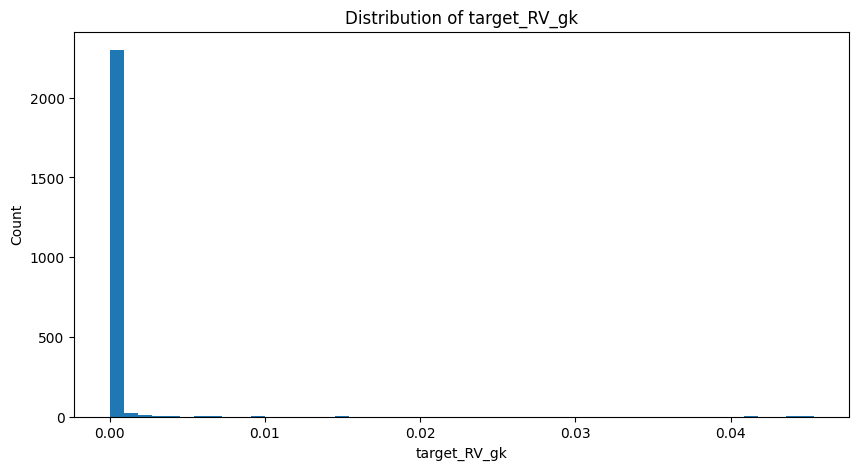

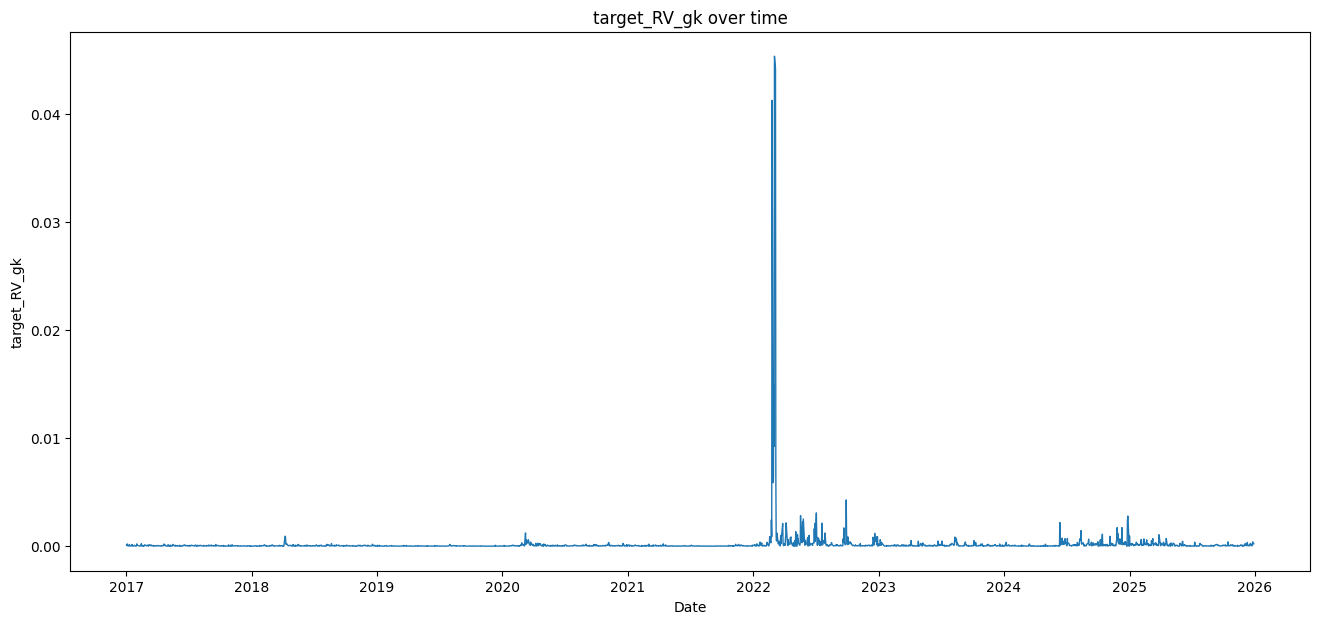

In [ ]:
if TARGET_COL not in data.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataframe.")

target_series = data[TARGET_COL].dropna()

print(target_series.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

plt.figure(figsize=(10, 5))
plt.hist(target_series, bins=50)
plt.title(f"Distribution of {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.show()

if DATE_COL in data.columns:
    plt.figure(figsize=FIGSIZE_WIDE)
    plt.plot(data[DATE_COL], data[TARGET_COL], linewidth=1)
    plt.title(f"{TARGET_COL} over time")
    plt.xlabel(DATE_COL)
    plt.ylabel(TARGET_COL)
    plt.show()


,feature,missing_cnt,missing_share,non_missing
103,key_rate_rf_days_since_change,60,0.025565,2287
73,ru10y_dbp_std_20,19,0.008095,2328
79,ru2y_dbp_std_20,19,0.008095,2328
85,ru1y_dbp_std_20,19,0.008095,2328
91,ru3m_dbp_std_20,19,0.008095,2328
4,key_rate_rf_19,5,0.002130,2342
100,key_rate_rf_level,5,0.002130,2342
72,ru10y_dbp_ma_5,4,0.001704,2343
78,ru2y_dbp_ma_5,4,0.001704,2343
84,ru1y_dbp_ma_5,4,0.001704,2343


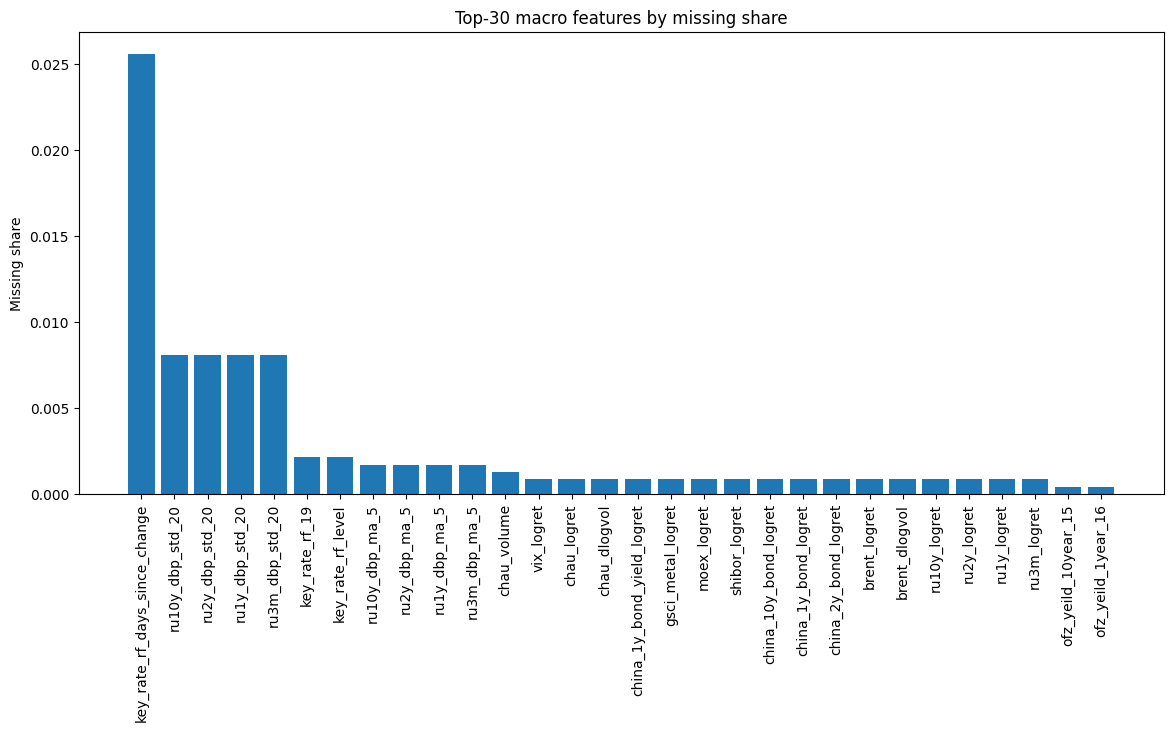

In [ ]:
missing_macro = pd.DataFrame({
    "feature": macro_cols,
    "missing_cnt": [data[c].isna().sum() for c in macro_cols],
    "missing_share": [data[c].isna().mean() for c in macro_cols],
    "non_missing": [data[c].notna().sum() for c in macro_cols]
}).sort_values(["missing_share", "missing_cnt"], ascending=False)

display(missing_macro.head(50))

plt.figure(figsize=(14, 6))
plt.bar(missing_macro["feature"].head(30), missing_macro["missing_share"].head(30))
plt.xticks(rotation=90)
plt.title("Top-30 macro features by missing share")
plt.ylabel("Missing share")
plt.show()


In [ ]:
rows = []
for col in macro_cols:
    tmp = data[[col, TARGET_COL]].dropna()
    if len(tmp) < 20:
        continue
    pearson = tmp[col].corr(tmp[TARGET_COL], method="pearson")
    spearman = tmp[col].corr(tmp[TARGET_COL], method="spearman")
    rows.append({
        "feature": col,
        "n_obs": len(tmp),
        "pearson": pearson,
        "abs_pearson": abs(pearson) if pd.notna(pearson) else np.nan,
        "spearman": spearman,
        "abs_spearman": abs(spearman) if pd.notna(spearman) else np.nan,
        "mean": tmp[col].mean(),
        "std": tmp[col].std()
    })

corr_target_df = pd.DataFrame(rows).sort_values("abs_spearman", ascending=False).reset_index(drop=True)

print("Top features by |abs| Spearman correlation with target:")
display(corr_target_df.head(TOP_N_TARGET_CORR))

print("\nTop features by |abs| Pearson correlation with target:")
display(corr_target_df.sort_values("abs_pearson", ascending=False).head(TOP_N_TARGET_CORR))


Top features by |abs| Spearman correlation with target:


,feature,n_obs,pearson,abs_pearson,spearman,abs_spearman,mean,std
0,usd_rub_range,2346,0.340558,0.340558,0.514210,0.514210,0.023207,0.027698
1,ru2y_dbp_std_20,2327,0.387660,0.387660,0.445431,0.445431,10.247380,14.044180
2,ru1y_dbp_std_20,2327,0.385279,0.385279,0.421941,0.421941,12.045624,15.784543
3,ru3m_dbp_std_20,2327,0.356535,0.356535,0.410750,0.410750,16.772901,18.692903
4,ru10y_dbp_std_20,2327,0.341582,0.341582,0.386849,0.386849,8.193899,7.856286
5,moex_range,2345,0.312909,0.312909,0.360382,0.360382,0.016145,0.017970
6,shibor_level,2345,-0.047654,0.047654,-0.341384,0.341384,2.689224,0.866630
7,ofz_yeild_2year_17,2345,0.073664,0.073664,0.331655,0.331655,9.421070,4.062175
8,ru2y_level,2345,0.073664,0.073664,0.331655,0.331655,9.421070,4.062175
9,ru10y_level,2345,0.071440,0.071440,0.328974,0.328974,9.751471,3.115898



Top features by |abs| Pearson correlation with target:


,feature,n_obs,pearson,abs_pearson,spearman,abs_spearman,mean,std
1,ru2y_dbp_std_20,2327,0.387660,0.387660,0.445431,0.445431,10.247380,14.044180
2,ru1y_dbp_std_20,2327,0.385279,0.385279,0.421941,0.421941,12.045624,15.784543
3,ru3m_dbp_std_20,2327,0.356535,0.356535,0.410750,0.410750,16.772901,18.692903
4,ru10y_dbp_std_20,2327,0.341582,0.341582,0.386849,0.386849,8.193899,7.856286
0,usd_rub_range,2346,0.340558,0.340558,0.514210,0.514210,0.023207,0.027698
5,moex_range,2345,0.312909,0.312909,0.360382,0.360382,0.016145,0.017970
49,brent_volume,2345,0.288183,0.288183,0.095560,0.095560,"690,850.618337","874,736.773406"
66,moex_oc,2345,0.250668,0.250668,-0.042405,0.042405,0.000340,0.015394
85,usd_rub_logret,2345,0.189247,0.189247,0.020925,0.020925,0.000106,0.014730
27,ru2y_d_abs_bp,2346,0.181191,0.181191,0.240981,0.240981,7.080989,15.872206


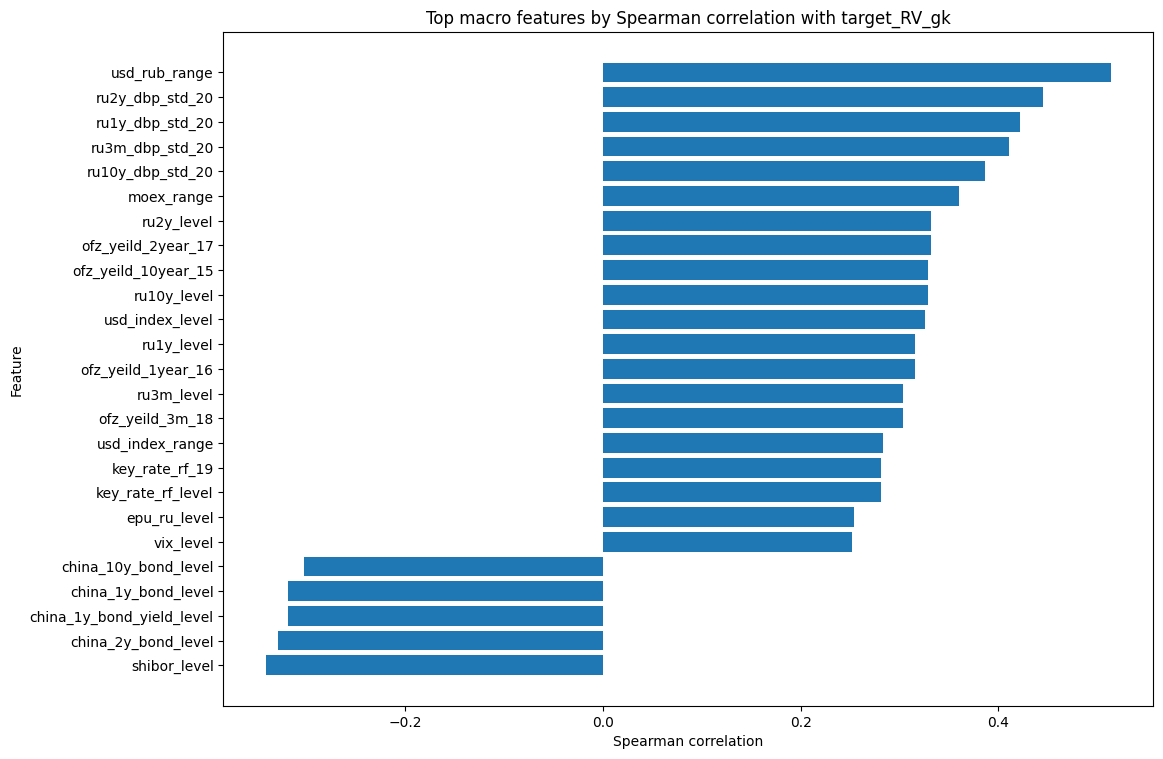

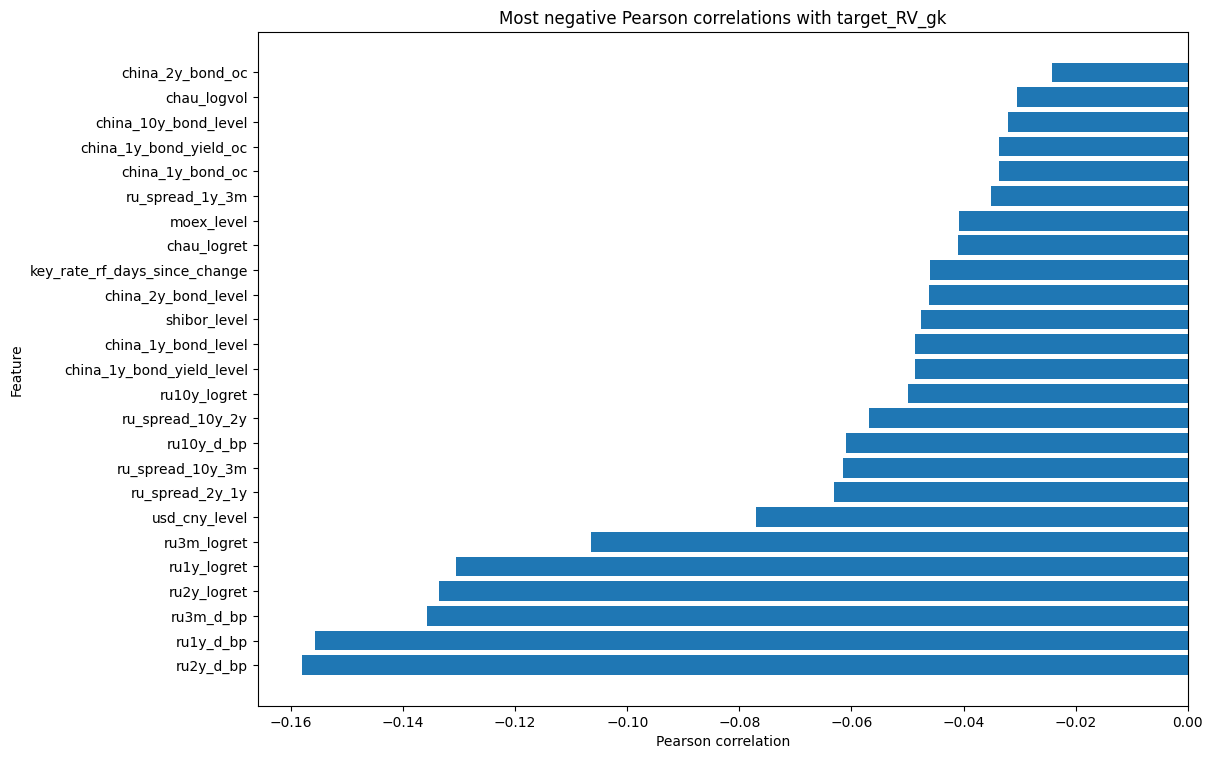

In [ ]:
top_corr = corr_target_df.head(min(TOP_N_TARGET_CORR, len(corr_target_df))).copy()
top_corr = top_corr.sort_values("spearman")

plt.figure(figsize=(12, max(6, 0.35 * len(top_corr))))
plt.barh(top_corr["feature"], top_corr["spearman"])
plt.title(f"Top macro features by Spearman correlation with {TARGET_COL}")
plt.xlabel("Spearman correlation")
plt.ylabel("Feature")
plt.show()

top_corr_p = corr_target_df.sort_values("pearson").head(min(TOP_N_TARGET_CORR, len(corr_target_df)))
plt.figure(figsize=(12, max(6, 0.35 * len(top_corr_p))))
plt.barh(top_corr_p["feature"], top_corr_p["pearson"])
plt.title(f"Most negative Pearson correlations with {TARGET_COL}")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.show()


,usd_rub_range,ru2y_dbp_std_20,ru1y_dbp_std_20,ru3m_dbp_std_20,ru10y_dbp_std_20,moex_range,shibor_level,ofz_yeild_2year_17,ru2y_level,ru10y_level,ofz_yeild_10year_15,china_2y_bond_level,usd_index_level,china_1y_bond_yield_level,china_1y_bond_level,ofz_yeild_1year_16,ru1y_level,ofz_yeild_3m_18,ru3m_level,china_10y_bond_level,usd_index_range,key_rate_rf_level,key_rate_rf_19,epu_ru_level,vix_level
usd_rub_range,1.000000,0.506000,0.501000,0.494000,0.324000,0.350000,-0.500000,0.353000,0.353000,0.405000,0.405000,-0.448000,0.557000,-0.433000,-0.433000,0.307000,0.307000,0.286000,0.286000,-0.429000,0.365000,0.229000,0.229000,0.398000,0.356000
ru2y_dbp_std_20,0.506000,1.000000,0.939000,0.827000,0.805000,0.400000,-0.674000,0.719000,0.719000,0.708000,0.708000,-0.695000,0.586000,-0.676000,-0.676000,0.688000,0.688000,0.667000,0.667000,-0.701000,0.246000,0.629000,0.629000,0.358000,0.237000
ru1y_dbp_std_20,0.501000,0.939000,1.000000,0.925000,0.729000,0.363000,-0.667000,0.744000,0.744000,0.745000,0.745000,-0.719000,0.626000,-0.702000,-0.702000,0.715000,0.715000,0.696000,0.696000,-0.719000,0.224000,0.674000,0.674000,0.335000,0.166000
ru3m_dbp_std_20,0.494000,0.827000,0.925000,1.000000,0.654000,0.328000,-0.677000,0.693000,0.693000,0.701000,0.701000,-0.756000,0.641000,-0.729000,-0.729000,0.664000,0.664000,0.649000,0.649000,-0.753000,0.197000,0.652000,0.652000,0.402000,0.189000
ru10y_dbp_std_20,0.324000,0.805000,0.729000,0.654000,1.000000,0.388000,-0.549000,0.552000,0.552000,0.516000,0.516000,-0.566000,0.399000,-0.554000,-0.554000,0.549000,0.549000,0.538000,0.538000,-0.559000,0.173000,0.491000,0.491000,0.283000,0.299000
moex_range,0.350000,0.400000,0.363000,0.328000,0.388000,1.000000,-0.294000,0.201000,0.201000,0.181000,0.181000,-0.262000,0.188000,-0.269000,-0.269000,0.186000,0.186000,0.180000,0.180000,-0.230000,0.222000,0.155000,0.155000,0.290000,0.391000
shibor_level,-0.500000,-0.674000,-0.667000,-0.677000,-0.549000,-0.294000,1.000000,-0.535000,-0.535000,-0.585000,-0.585000,0.946000,-0.668000,0.951000,0.951000,-0.486000,-0.486000,-0.458000,-0.458000,0.917000,-0.178000,-0.394000,-0.394000,-0.497000,-0.423000
ofz_yeild_2year_17,0.353000,0.719000,0.744000,0.693000,0.552000,0.201000,-0.535000,1.000000,1.000000,0.961000,0.961000,-0.637000,0.674000,-0.613000,-0.613000,0.991000,0.991000,0.970000,0.970000,-0.671000,0.095000,0.923000,0.923000,0.044000,-0.130000
ru2y_level,0.353000,0.719000,0.744000,0.693000,0.552000,0.201000,-0.535000,1.000000,1.000000,0.961000,0.961000,-0.637000,0.674000,-0.613000,-0.613000,0.991000,0.991000,0.970000,0.970000,-0.671000,0.095000,0.923000,0.923000,0.044000,-0.130000
ru10y_level,0.405000,0.708000,0.745000,0.701000,0.516000,0.181000,-0.585000,0.961000,0.961000,1.000000,1.000000,-0.670000,0.696000,-0.649000,-0.649000,0.932000,0.932000,0.909000,0.909000,-0.697000,0.129000,0.870000,0.870000,0.096000,-0.072000


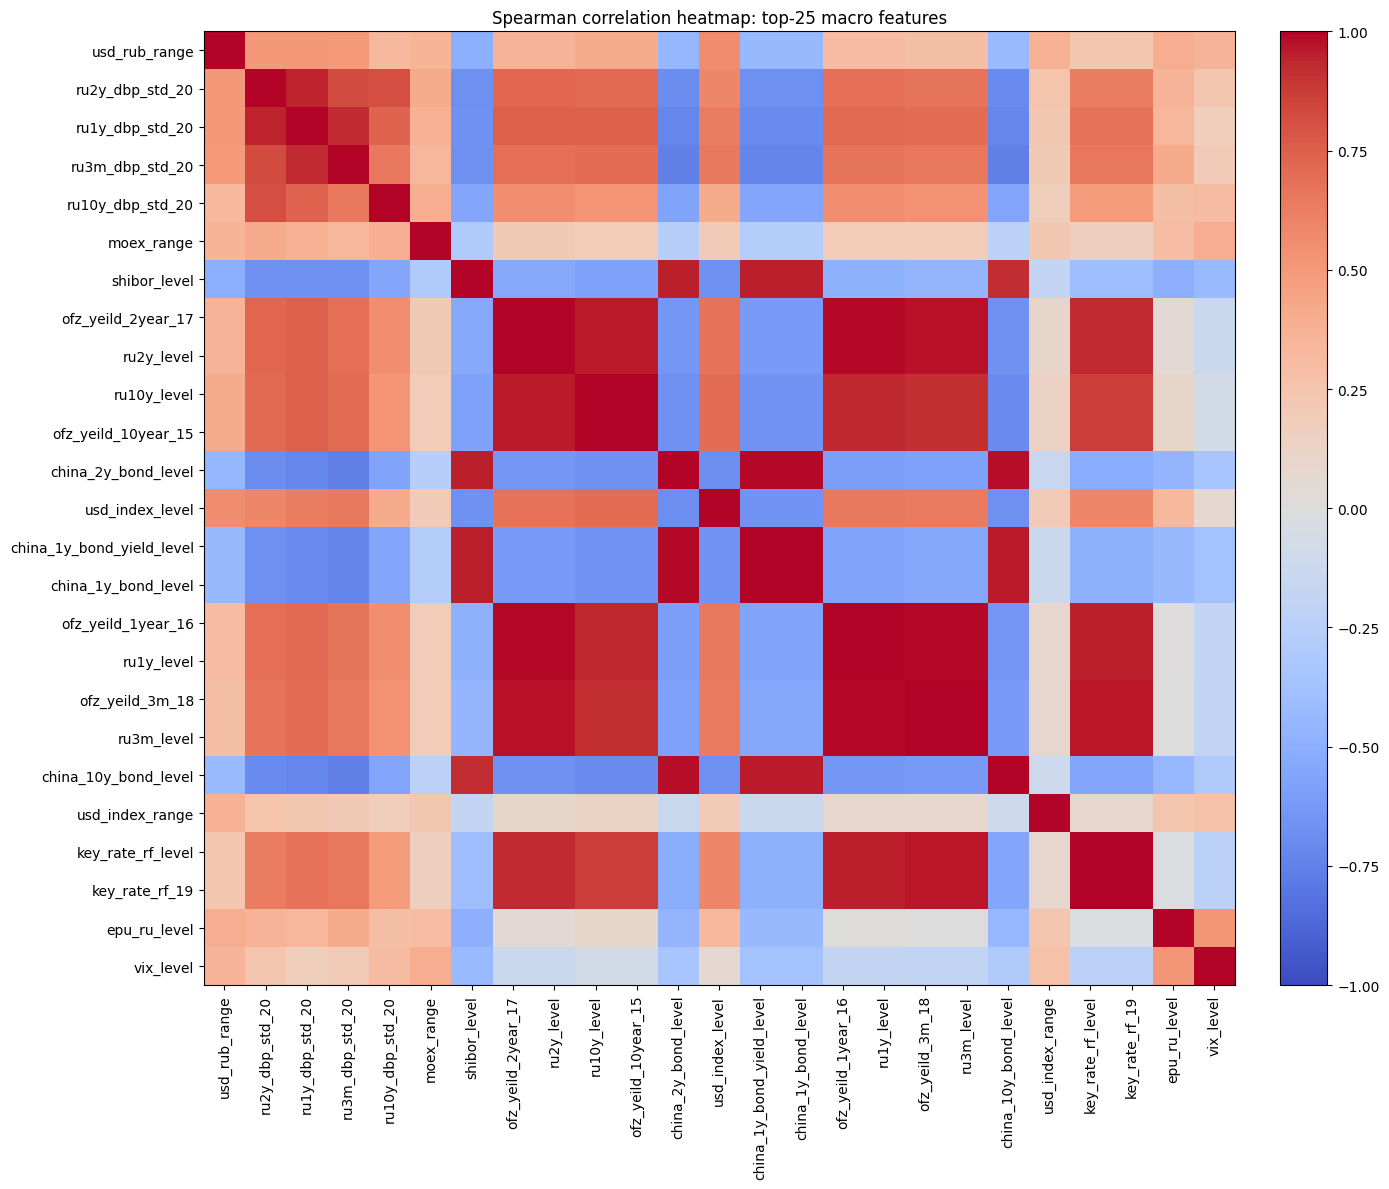

In [ ]:
def plot_corr_heatmap(df_corr, title="", figsize=(12, 10), cmap="coolwarm", vmin=-1, vmax=1):
    plt.figure(figsize=figsize)
    im = plt.imshow(df_corr.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=90)
    plt.yticks(range(len(df_corr.index)), df_corr.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

top_macro_for_heatmap = corr_target_df.head(min(TOP_N_HEATMAP, len(corr_target_df)))["feature"].tolist()
heatmap_df = data[top_macro_for_heatmap].corr(method="spearman")

display(heatmap_df.round(3).head(20))
plot_corr_heatmap(
    heatmap_df,
    title=f"Spearman correlation heatmap: top-{len(top_macro_for_heatmap)} macro features",
    figsize=FIGSIZE_HEATMAP
)


In [ ]:


macro_corr_full = data[macro_cols].corr(method="spearman")
pairs = []

cols = macro_corr_full.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        val = macro_corr_full.loc[c1, c2]
        if pd.notna(val) and abs(val) >= HIGH_CORR_THRESHOLD:
            pairs.append({
                "feature_1": c1,
                "feature_2": c2,
                "spearman_corr": val,
                "abs_corr": abs(val)
            })

high_corr_pairs = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)

print(f"Pairs with |Spearman correlation| >= {HIGH_CORR_THRESHOLD}:")
display(high_corr_pairs.head(100))


Pairs with |Spearman correlation| >= 0.85:


,feature_1,feature_2,spearman_corr,abs_corr
0,ofz_yeild_1year_16,ru1y_level,1.000000,1.000000
1,ofz_yeild_10year_15,ru10y_level,1.000000,1.000000
2,ofz_yeild_3m_18,ru3m_level,1.000000,1.000000
3,ofz_yeild_2year_17,ru2y_level,1.000000,1.000000
4,chau_volume,chau_logvol,1.000000,1.000000
5,china_1y_bond_yield_level,china_1y_bond_level,1.000000,1.000000
6,china_1y_bond_yield_d_bp,china_1y_bond_d_bp,1.000000,1.000000
7,china_1y_bond_yield_logret,china_1y_bond_logret,1.000000,1.000000
8,china_1y_bond_yield_range,china_1y_bond_range,1.000000,1.000000
9,key_rate_rf_19,key_rate_rf_level,1.000000,1.000000


In [ ]:
y=data['target_RV_gk']

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_excel('/content/result_hope_8_march.xlsx')

In [ ]:


import re
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

DATE_COL = "Date"
TARGET_COL = "target_RV_gk"
RV_COL = "RV_gk"

TRAIN_END = "2023-12-31"
VAL_END   = "2024-12-31"

EPS = 1e-12
RANDOM_STATE = 42

MAX_MISSING_SHARE = 0.35

EXACT_CORR_THR = 0.999999

CLUSTER_CORR_THR = 0.95

MAX_SELECTED_MACRO_COLS = 35

DROP_UNNAMED_RAW_OHLC = True

MAKE_MODELREADY_SCALED_DATASET = True

SCALE_MANUAL_KEEP_COLS = True

SAVE_REPORTS = True


MANUAL_KEEP_COLS = [
    "cnyrub_logret",
    # "cnyrub_range",
    # "cnyrub_oc",
    # "cnyrub_gap",
    # "usd_rub_logret",
    # "usd_cny_logret",
    # "vix_logret",
    # "brent_logret",
]


def make_unique_columns(cols):
    seen = {}
    out = []

    for c in cols:
        c = str(c).strip()

        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}__dup{seen[c]}")

    return out


def to_numeric_clean(s):
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)

    x = s.astype(str).str.strip()
    x = x.str.replace("\u00a0", "", regex=False)
    x = x.str.replace(" ", "", regex=False)
    x = x.str.replace("%", "", regex=False)
    x = x.str.replace("−", "-", regex=False)

    def clean_one(v):
        if v.lower() in ["", "nan", "none", "nat", "null"]:
            return np.nan
        if "," in v and "." not in v:
            return v.replace(",", ".")
        if "," in v and "." in v:
            return v.replace(",", "")
        return v

    x = x.map(clean_one)

    return pd.to_numeric(x, errors="coerce")


def is_raw_ohlc_name(c):
    pattern = r"^(Price|Open|High|Low|Close|Vol\.?|Change\s*%)_\d+$|^(open|high|low|close|volume)_\d+$"
    return bool(re.match(pattern, str(c), flags=re.IGNORECASE))


def is_forbidden_auto_feature(c):

    lc = str(c).lower()

    if c == DATE_COL:
        return True

    if "target" in lc:
        return True

    if c == RV_COL:
        return True

    if lc.startswith("cnyrub_"):
        return True

    if lc in ["rv", "rv_gk"]:
        return True
    if DROP_UNNAMED_RAW_OHLC and is_raw_ohlc_name(c):
        return True

    return False


def is_forbidden_manual_feature(c):
    lc = str(c).lower()

    if c == DATE_COL:
        return True

    if c == TARGET_COL:
        return True

    if lc in ["target_rv_gk", "target_vol_gk"]:
        return True

    if "target" in lc:
        return True

    return False


def name_preference(c):

    lc = str(c).lower()
    pref = 0.0

    if not is_raw_ohlc_name(c):
        pref += 0.10

    good_parts = [
        "logret", "range", "_oc", "d_bp", "d_abs_bp",
        "std_20", "ma_5", "dlogvol", "logvol",
        "changed", "days_since_change", "spread", "dummy"
    ]

    if any(x in lc for x in good_parts):
        pref += 0.10

    if "level" in lc:
        pref += 0.03

    if is_raw_ohlc_name(c):
        pref -= 0.10

    return pref


def corr_components(corr_df, threshold):
    if corr_df.shape[1] == 0:
        return []

    cols = list(corr_df.columns)
    values = corr_df.values
    visited = set()
    components = []

    for i, c in enumerate(cols):
        if c in visited:
            continue

        stack = [i]
        visited.add(c)
        comp = []

        while stack:
            idx = stack.pop()
            comp.append(cols[idx])

            neighbors = np.where(values[idx] >= threshold)[0]

            for j in neighbors:
                cj = cols[j]
                if cj not in visited:
                    visited.add(cj)
                    stack.append(j)

        components.append(sorted(comp))

    return components


def safe_spearman_scores(X, y):
    scores = {}

    for c in X.columns:
        try:
            val = X[c].corr(y, method="spearman")
            if pd.isna(val) or np.isinf(val):
                val = 0.0
            scores[c] = abs(float(val))
        except Exception:
            scores[c] = 0.0

    return pd.Series(scores)


def compute_feature_scores(X_train, y_train):

    if X_train.shape[1] == 0:
        empty_score = pd.Series(dtype=float)
        empty_table = pd.DataFrame(columns=[
            "feature",
            "smart_score",
            "abs_spearman_log_target",
            "mutual_info_log_target",
            "random_forest_importance",
            "missing_share_train",
            "name_preference"
        ])
        return empty_score, empty_table

    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    y_train = pd.Series(y_train, index=X_train.index)
    y_train = y_train.replace([np.inf, -np.inf], np.nan)

    valid = y_train.notna()

    X = X_train.loc[valid].copy()
    y = y_train.loc[valid].copy()

    spearman = safe_spearman_scores(X, y).fillna(0.0)

    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X)

    try:
        mi = mutual_info_regression(
            X_imp,
            y.values,
            random_state=RANDOM_STATE
        )
        mi = pd.Series(mi, index=X.columns).fillna(0.0)
    except Exception:
        mi = pd.Series(0.0, index=X.columns)

    try:
        rf = RandomForestRegressor(
            n_estimators=400,
            max_depth=4,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_imp, y.values)
        rf_imp = pd.Series(rf.feature_importances_, index=X.columns).fillna(0.0)
    except Exception:
        rf_imp = pd.Series(0.0, index=X.columns)

    missing_penalty = X_train.isna().mean().reindex(X.columns).fillna(1.0)
    pref = pd.Series({c: name_preference(c) for c in X.columns})

    spearman_rank = spearman.rank(pct=True).fillna(0.0)
    mi_rank = mi.rank(pct=True).fillna(0.0)
    rf_rank = rf_imp.rank(pct=True).fillna(0.0)

    score = (
        0.35 * spearman_rank
        + 0.25 * mi_rank
        + 0.30 * rf_rank
        + 0.10 * pref
        - 0.10 * missing_penalty
    )

    score = score.sort_values(ascending=False)

    score_table = pd.DataFrame({
        "feature": score.index,
        "smart_score": score.values,
        "abs_spearman_log_target": spearman.reindex(score.index).values,
        "mutual_info_log_target": mi.reindex(score.index).values,
        "random_forest_importance": rf_imp.reindex(score.index).values,
        "missing_share_train": missing_penalty.reindex(score.index).values,
        "name_preference": pref.reindex(score.index).values,
    })

    return score, score_table


def pick_best_feature(group, score):
    return sorted(
        group,
        key=lambda c: (
            score.get(c, -999),
            name_preference(c),
            -len(str(c))
        ),
        reverse=True
    )[0]


df_work = df.copy()
df_work.columns = make_unique_columns(df_work.columns)

df_work[DATE_COL] = pd.to_datetime(df_work[DATE_COL], dayfirst=True, errors="coerce")
df_work = df_work.sort_values(DATE_COL).reset_index(drop=True)

for c in df_work.columns:
    if c != DATE_COL:
        df_work[c] = to_numeric_clean(df_work[c])

df_work = df_work.replace([np.inf, -np.inf], np.nan)
df_work = df_work.dropna(subset=[DATE_COL, TARGET_COL]).reset_index(drop=True)

train_mask = df_work[DATE_COL] <= pd.to_datetime(TRAIN_END)
val_mask = (df_work[DATE_COL] > pd.to_datetime(TRAIN_END)) & (df_work[DATE_COL] <= pd.to_datetime(VAL_END))
oos_mask = df_work[DATE_COL] > pd.to_datetime(VAL_END)

print("========== DATA RANGE ==========")
print("Data range:", df_work[DATE_COL].min(), "->", df_work[DATE_COL].max())
print("Train rows:", int(train_mask.sum()))
print("Validation rows:", int(val_mask.sum()))
print("OOS rows:", int(oos_mask.sum()))



numeric_cols = [
    c for c in df_work.columns
    if c != DATE_COL and pd.api.types.is_numeric_dtype(df_work[c])
]

macro_candidate_cols = [
    c for c in numeric_cols
    if not is_forbidden_auto_feature(c)
]

X_all = df_work[macro_candidate_cols].copy()
X_train = X_all.loc[train_mask].copy()

y_all = np.log(df_work[TARGET_COL].clip(lower=EPS))
y_train = y_all.loc[train_mask].copy()

print("\n========== INITIAL CANDIDATES ==========")
print("Initial automatic macro candidates:", len(macro_candidate_cols))

missing_share = X_train.isna().mean()
drop_missing = missing_share[missing_share > MAX_MISSING_SHARE].index.tolist()

X_all_1 = X_all.drop(columns=drop_missing)
X_train_1 = X_train.drop(columns=drop_missing)

nunique = X_train_1.nunique(dropna=True)
drop_constant = nunique[nunique <= 1].index.tolist()

X_all_2 = X_all_1.drop(columns=drop_constant)
X_train_2 = X_train_1.drop(columns=drop_constant)

print("\n========== BASIC FILTERING ==========")
print("Dropped by missingness:", len(drop_missing))
print("Dropped constants:", len(drop_constant))
print("After basic cleaning:", X_train_2.shape[1])



feature_score, feature_score_table = compute_feature_scores(X_train_2, y_train)


if X_train_2.shape[1] > 1:
    corr_exact = X_train_2.corr(method="pearson").abs().fillna(0.0)
    np.fill_diagonal(corr_exact.values, 1.0)

    exact_components = corr_components(corr_exact, EXACT_CORR_THR)
    exact_groups = [g for g in exact_components if len(g) > 1]
else:
    exact_components = [[c] for c in X_train_2.columns]
    exact_groups = []

exact_drop = set()
exact_rows = []

for group_id, group in enumerate(exact_groups, start=1):
    rep = pick_best_feature(group, feature_score)

    for c in group:
        dropped = c != rep

        if dropped:
            exact_drop.add(c)

        exact_rows.append({
            "exact_group": group_id,
            "feature": c,
            "kept_feature": rep,
            "dropped": dropped,
            "smart_score": feature_score.get(c, np.nan),
        })

exact_duplicate_report = pd.DataFrame(exact_rows)

X_all_3 = X_all_2.drop(columns=list(exact_drop))
X_train_3 = X_train_2.drop(columns=list(exact_drop))

print("\n========== EXACT DUPLICATES ==========")
print("Exact duplicate groups:", len(exact_groups))
print("Dropped exact duplicates:", len(exact_drop))
print("After duplicate removal:", X_train_3.shape[1])

feature_score_2, feature_score_table_2 = compute_feature_scores(X_train_3, y_train)


if X_train_3.shape[1] > 1:
    corr_cluster = X_train_3.corr(method="spearman").abs().fillna(0.0)
    np.fill_diagonal(corr_cluster.values, 1.0)

    cluster_components = corr_components(corr_cluster, CLUSTER_CORR_THR)
else:
    cluster_components = [[c] for c in X_train_3.columns]

selected_after_clusters = []
cluster_rows = []

for group_id, group in enumerate(cluster_components, start=1):
    if len(group) == 1:
        selected_after_clusters.append(group[0])
    else:
        rep = pick_best_feature(group, feature_score_2)
        selected_after_clusters.append(rep)

        for c in group:
            cluster_rows.append({
                "cluster": group_id,
                "feature": c,
                "kept_feature": rep,
                "dropped": c != rep,
                "smart_score": feature_score_2.get(c, np.nan),
            })

cluster_report = pd.DataFrame(cluster_rows)

selected_after_clusters = list(dict.fromkeys(selected_after_clusters))

selected_macro_cols = (
    feature_score_2
    .reindex(selected_after_clusters)
    .dropna()
    .sort_values(ascending=False)
    .head(MAX_SELECTED_MACRO_COLS)
    .index
    .tolist()
)

print("\n========== HIGH-CORRELATION CLUSTERS ==========")
print("High-correlation clusters:", len([g for g in cluster_components if len(g) > 1]))
print("Automatically selected macro columns:", len(selected_macro_cols))
manual_missing_cols = [c for c in MANUAL_KEEP_COLS if c not in df_work.columns]

manual_forbidden_cols = [
    c for c in MANUAL_KEEP_COLS
    if c in df_work.columns and is_forbidden_manual_feature(c)
]

manual_extra_cols = [
    c for c in MANUAL_KEEP_COLS
    if c in df_work.columns
    and not is_forbidden_manual_feature(c)
    and c not in selected_macro_cols
]

manual_extra_cols = [
    c for c in manual_extra_cols
    if c != RV_COL
]

final_feature_cols = selected_macro_cols + manual_extra_cols
final_feature_cols = list(dict.fromkeys(final_feature_cols))

print("\n========== MANUAL COLUMNS ==========")
print("Manual columns requested:", MANUAL_KEEP_COLS)
print("Manual columns missing:", manual_missing_cols)
print("Manual columns forbidden / skipped:", manual_forbidden_cols)
print("Manual columns added:", manual_extra_cols)
print("Final feature columns:", len(final_feature_cols))


base_cols = [DATE_COL, TARGET_COL, RV_COL]
base_cols = [c for c in base_cols if c in df_work.columns]

final_raw_cols = base_cols + final_feature_cols
final_raw_cols = list(dict.fromkeys(final_raw_cols))

df_macro_selected_raw = df_work[final_raw_cols].copy()

print("\n========== FINAL RAW DATASET ==========")
print("Final raw dataset shape:", df_macro_selected_raw.shape)



if MAKE_MODELREADY_SCALED_DATASET:

    if SCALE_MANUAL_KEEP_COLS:
        scaled_feature_cols = final_feature_cols.copy()
        unscaled_manual_cols = []
    else:
        scaled_feature_cols = selected_macro_cols.copy()
        unscaled_manual_cols = manual_extra_cols.copy()

    pieces = [df_work[base_cols].reset_index(drop=True)]

    if len(scaled_feature_cols) > 0:
        X_sel_all = df_work[scaled_feature_cols].copy()
        X_sel_train = X_sel_all.loc[train_mask].copy()

        imputer_final = SimpleImputer(strategy="median")

        X_train_imp = pd.DataFrame(
            imputer_final.fit_transform(X_sel_train),
            index=X_sel_train.index,
            columns=scaled_feature_cols
        )

        clip_low = X_train_imp.quantile(0.01)
        clip_high = X_train_imp.quantile(0.99)

        def transform_selected_features(X):
            X_imp = pd.DataFrame(
                imputer_final.transform(X),
                index=X.index,
                columns=scaled_feature_cols
            )

            X_clip = X_imp.clip(lower=clip_low, upper=clip_high, axis=1)

            return X_clip

        X_all_clip = transform_selected_features(X_sel_all)

        scaler_final = RobustScaler(quantile_range=(5, 95))
        scaler_final.fit(X_all_clip.loc[train_mask])

        X_all_scaled = pd.DataFrame(
            scaler_final.transform(X_all_clip),
            index=X_all_clip.index,
            columns=scaled_feature_cols
        )

        pieces.append(X_all_scaled.reset_index(drop=True))

    if len(unscaled_manual_cols) > 0:
        pieces.append(df_work[unscaled_manual_cols].reset_index(drop=True))

    df_macro_selected_modelready = pd.concat(pieces, axis=1)

    df_macro_selected_modelready = df_macro_selected_modelready.loc[
        :,
        ~df_macro_selected_modelready.columns.duplicated()
    ]

    print("\n========== FINAL MODEL-READY DATASET ==========")
    print("Scaled feature columns:", scaled_feature_cols)
    print("Unscaled manual columns:", unscaled_manual_cols)
    print("Final model-ready dataset shape:", df_macro_selected_modelready.shape)

else:
    df_macro_selected_modelready = df_macro_selected_raw.copy()

selected_features_report = feature_score_table_2[
    feature_score_table_2["feature"].isin(selected_macro_cols)
].copy()

if len(selected_features_report) > 0:
    selected_features_report["final_rank"] = (
        selected_features_report["smart_score"]
        .rank(ascending=False, method="first")
        .astype(int)
    )

    selected_features_report = selected_features_report.sort_values("final_rank")

manual_features_report = pd.DataFrame({
    "manual_feature": MANUAL_KEEP_COLS,
    "exists_in_df": [c in df_work.columns for c in MANUAL_KEEP_COLS],
    "added_to_final_dataset": [c in manual_extra_cols for c in MANUAL_KEEP_COLS],
    "forbidden_or_skipped": [
        (c in manual_forbidden_cols) or (c == RV_COL) for c in MANUAL_KEEP_COLS
    ],
})

summary_report = pd.DataFrame({
    "stage": [
        "initial_auto_macro_candidates",
        "dropped_missing",
        "dropped_constant",
        "dropped_exact_duplicates",
        "selected_after_high_corr_clustering",
        "final_auto_selected_macro_cols",
        "manual_cols_added",
        "final_feature_cols"
    ],
    "count": [
        len(macro_candidate_cols),
        len(drop_missing),
        len(drop_constant),
        len(exact_drop),
        len(selected_after_clusters),
        len(selected_macro_cols),
        len(manual_extra_cols),
        len(final_feature_cols)
    ]
})

print("\n========== FEATURE SELECTION SUMMARY ==========")
display(summary_report)

print("\n========== SELECTED AUTOMATIC MACRO FEATURES ==========")
display(selected_features_report)

print("\n========== MANUAL FEATURES REPORT ==========")
display(manual_features_report)

if len(cluster_report) > 0:
    print("\n========== HIGH-CORRELATION CLUSTERS ==========")
    display(cluster_report.head(100))

if len(exact_duplicate_report) > 0:
    print("\n========== EXACT DUPLICATES ==========")
    display(exact_duplicate_report.head(100))

if SAVE_REPORTS:
    df_macro_selected_raw.to_excel("df_macro_selected_raw.xlsx", index=False)
    df_macro_selected_modelready.to_excel("df_macro_selected_modelready_fin.xlsx", index=False)

    with pd.ExcelWriter("macro_feature_selection_report.xlsx") as writer:
        summary_report.to_excel(writer, sheet_name="summary", index=False)
        selected_features_report.to_excel(writer, sheet_name="selected_auto_features", index=False)
        manual_features_report.to_excel(writer, sheet_name="manual_features", index=False)
        feature_score_table_2.to_excel(writer, sheet_name="all_auto_feature_scores", index=False)
        exact_duplicate_report.to_excel(writer, sheet_name="exact_duplicates", index=False)
        cluster_report.to_excel(writer, sheet_name="corr_clusters", index=False)

    print("\n========== SAVED FILES ==========")
    print("- df_macro_selected_raw.xlsx")
    print("- df_macro_selected_modelready.xlsx")
    print("- macro_feature_selection_report.xlsx")

print("\n========== OBJECTS TO USE ==========")

print("\nAutomatically selected macro columns:")
print("selected_macro_cols =")
print(selected_macro_cols)

print("\nManually added columns:")
print("manual_extra_cols =")
print(manual_extra_cols)

print("\nFinal model feature columns:")
print("final_feature_cols =")
print(final_feature_cols)

print("\nUse this dataframe for models:")
print("df_macro_selected_modelready")

print("\nTarget column:")
print(TARGET_COL)

print("\nExample:")
print("model_df = df_macro_selected_modelready.copy()")
print("X_cols = final_feature_cols + [RV_COL]")
print("X_cols = list(dict.fromkeys([c for c in X_cols if c in model_df.columns and c != TARGET_COL]))")
print("X = model_df[X_cols]")
print("y = model_df[TARGET_COL]")

========== DATA RANGE ==========
Data range: 2017-01-02 00:00:00 -> 2025-12-29 00:00:00
Train rows: 1825
Validation rows: 262
OOS rows: 259

========== INITIAL CANDIDATES ==========
Initial automatic macro candidates: 112

========== BASIC FILTERING ==========
Dropped by missingness: 0
Dropped constants: 2
After basic cleaning: 110

========== EXACT DUPLICATES ==========
Exact duplicate groups: 10
Dropped exact duplicates: 10
After duplicate removal: 100

========== HIGH-CORRELATION CLUSTERS ==========
High-correlation clusters: 15
Automatically selected macro columns: 35

========== MANUAL COLUMNS ==========
Manual columns requested: ['cnyrub_logret']
Manual columns missing: []
Manual columns forbidden / skipped: []
Manual columns added: ['cnyrub_logret']
Final feature columns: 36

========== FINAL RAW DATASET ==========
Final raw dataset shape: (2346, 39)

========== FINAL MODEL-READY DATASET ==========
Scaled feature columns: ['usd_rub_range', 'ru1y_dbp_std_20', 'ru2y_dbp_std_20', '

,stage,count
0,initial_auto_macro_candidates,112
1,dropped_missing,0
2,dropped_constant,2
3,dropped_exact_duplicates,10
4,selected_after_high_corr_clustering,82
5,final_auto_selected_macro_cols,35
6,manual_cols_added,1
7,final_feature_cols,36



========== SELECTED AUTOMATIC MACRO FEATURES ==========


,feature,smart_score,abs_spearman_log_target,mutual_info_log_target,random_forest_importance,missing_share_train,name_preference,final_rank
0,usd_rub_range,0.920000,0.554435,0.252243,0.122848,0.000000,0.200000,1
1,ru1y_dbp_std_20,0.888959,0.394580,0.186871,0.044127,0.010411,0.200000,2
2,ru2y_dbp_std_20,0.885959,0.425168,0.173640,0.051028,0.010411,0.200000,3
3,china_2y_bond_level,0.868445,0.290094,0.185932,0.051048,0.000548,0.130000,4
4,ru3m_dbp_std_20,0.863459,0.389423,0.150270,0.044453,0.010411,0.200000,5
5,moex_range,0.857945,0.345200,0.140852,0.065958,0.000548,0.200000,6
7,ru10y_dbp_std_20,0.831959,0.320909,0.118700,0.054796,0.010411,0.200000,7
8,ofz_yeild_2year_17,0.828445,0.289649,0.168143,0.032291,0.000548,0.100000,8
9,shibor_level,0.824445,0.272866,0.177737,0.030943,0.000548,0.130000,9
10,ru10y_level,0.810945,0.286627,0.141843,0.032995,0.000548,0.130000,10



========== MANUAL FEATURES REPORT ==========


...


========== HIGH-CORRELATION CLUSTERS ==========


,cluster,feature,kept_feature,dropped,smart_score
0,1,ofz_yeild_2year_17,ofz_yeild_2year_17,False,0.828445
1,1,ofz_yeild_3m_18,ofz_yeild_2year_17,True,0.736945
2,1,ru1y_level,ofz_yeild_2year_17,True,0.768445
3,10,chau_logvol,chau_logvol,False,0.568945
4,10,chau_volume,chau_logvol,True,0.544836
5,12,china_10y_bond_level,china_2y_bond_level,True,0.790445
6,12,china_1y_bond_yield_level,china_2y_bond_level,True,0.837445
7,12,china_2y_bond_level,china_2y_bond_level,False,0.868445
8,13,china_1y_bond_d_bp,china_1y_bond_d_bp,False,0.203500
9,13,china_1y_bond_yield_logret,china_1y_bond_d_bp,True,0.198890



========== EXACT DUPLICATES ==========


,exact_group,feature,kept_feature,dropped,smart_score
0,1,ofz_yeild_10year_15,ru10y_level,True,0.786991
1,1,ru10y_level,ru10y_level,False,0.790445
2,2,ofz_yeild_1year_16,ru1y_level,True,0.741991
3,2,ru1y_level,ru1y_level,False,0.761809
4,3,ofz_yeild_2year_17,ofz_yeild_2year_17,False,0.826991
5,3,ru2y_level,ofz_yeild_2year_17,True,0.822263
6,4,ofz_yeild_3m_18,ofz_yeild_3m_18,False,0.707900
7,4,ru3m_level,ofz_yeild_3m_18,True,0.703627
8,5,key_rate_rf_19,key_rate_rf_level,True,0.714953
9,5,key_rate_rf_level,key_rate_rf_level,False,0.737499



========== SAVED FILES ==========
- df_macro_selected_raw.xlsx
- df_macro_selected_modelready.xlsx
- macro_feature_selection_report.xlsx

========== OBJECTS TO USE ==========

Automatically selected macro columns:
selected_macro_cols =
['usd_rub_range', 'ru1y_dbp_std_20', 'ru2y_dbp_std_20', 'china_2y_bond_level', 'ru3m_dbp_std_20', 'moex_range', 'ru10y_dbp_std_20', 'ofz_yeild_2year_17', 'shibor_level', 'ru10y_level', 'brent_level', 'usd_index_level', 'epu_ru_level', 'key_rate_rf_level', 'vix_level', 'usd_index_range', 'gsci_metal_level', 'epu_diff_ru_cn_level', 'epu_diff_ru_cn_log', 'usd_rub_oc', 'gsci_metal_range', 'moex_level', 'usd_rub_logret', 'usd_rub_level', 'ru3m_dbp_ma_5', 'ru10y_dbp_ma_5', 'ru2y_d_abs_bp', 'epu_cn_proquest_level', 'chau_level', 'usd_cny_level', 'ru1y_dbp_ma_5', 'chau_logvol', 'china_2y_bond_range', 'brent_range', 'ru2y_dbp_ma_5']

Manually added columns:
manual_extra_cols =
['cnyrub_logret']

Final model feature columns:
final_feature_cols =
['usd_rub_range',

========== CORRELATION MATRIX AFTER EXACT DUPLICATE REMOVAL ==========
Correlation method: spearman
Number of features: 100
Matrix shape: (100, 100)


,ofz_yeild_2year_17,ofz_yeild_3m_18,vix_level,vix_logret,vix_range,vix_oc,chau_level,chau_logret,chau_range,chau_oc,chau_volume,chau_logvol,chau_dlogvol,china_1y_bond_yield_level,china_1y_bond_yield_logret,china_1y_bond_yield_range,china_1y_bond_yield_oc,gsci_metal_level,gsci_metal_logret,gsci_metal_range,gsci_metal_oc,moex_level,moex_logret,moex_range,moex_oc,usd_index_level,usd_index_logret,usd_index_range,usd_index_oc,usd_cny_level,usd_cny_logret,usd_cny_range,usd_cny_oc,usd_rub_level,usd_rub_logret,usd_rub_range,usd_rub_oc,shibor_level,shibor_d_bp,shibor_logret,china_10y_bond_level,china_10y_bond_d_bp,china_10y_bond_logret,china_10y_bond_range,china_10y_bond_oc,china_1y_bond_d_bp,china_2y_bond_level,china_2y_bond_d_bp,china_2y_bond_logret,china_2y_bond_range,china_2y_bond_oc,brent_level,brent_logret,brent_range,brent_oc,brent_volume,brent_logvol,brent_dlogvol,ru10y_level,ru10y_d_bp,ru10y_logret,ru10y_d_abs_bp,ru10y_dbp_ma_5,ru10y_dbp_std_20,ru2y_d_bp,ru2y_logret,ru2y_d_abs_bp,ru2y_dbp_ma_5,ru2y_dbp_std_20,ru1y_level,ru1y_d_bp,ru1y_logret,ru1y_d_abs_bp,ru1y_dbp_ma_5,ru1y_dbp_std_20,ru3m_d_bp,ru3m_logret,ru3m_d_abs_bp,ru3m_dbp_ma_5,ru3m_dbp_std_20,ru_spread_10y_2y,ru_spread_2y_1y,ru_spread_1y_3m,ru_spread_10y_3m,ru_spread_10y_2y_d_bp,ru_spread_2y_1y_d_bp,ru_spread_1y_3m_d_bp,ru_spread_10y_3m_d_bp,key_rate_rf_level,key_rate_rf_d_bp,key_rate_rf_changed,key_rate_rf_days_since_change,ru_tax_period_dummy,cn_tax_period_dummy,epu_ru_level,epu_cn_factiva_level,epu_cn_proquest_level,epu_cn_avg_level,epu_diff_ru_cn_level,epu_diff_ru_cn_log
ofz_yeild_2year_17,1.000000,0.944000,-0.142000,0.020000,-0.133000,-0.004000,-0.444000,-0.060000,-0.099000,-0.044000,-0.457000,-0.457000,0.008000,-0.269000,-0.015000,0.251000,-0.107000,0.405000,-0.059000,0.150000,-0.052000,-0.258000,-0.051000,0.187000,-0.010000,0.604000,0.049000,0.171000,0.042000,0.148000,0.063000,-0.087000,0.051000,0.085000,0.002000,0.430000,-0.087000,-0.213000,0.055000,0.056000,-0.321000,-0.018000,-0.020000,0.025000,-0.007000,-0.011000,-0.287000,-0.018000,-0.022000,0.108000,-0.083000,0.638000,-0.004000,0.065000,-0.036000,-0.084000,-0.084000,-0.000000,0.919000,0.046000,0.039000,0.100000,0.083000,0.248000,0.048000,0.051000,0.263000,0.113000,0.542000,0.982000,0.026000,0.033000,0.236000,0.096000,0.573000,0.020000,0.031000,0.232000,0.055000,0.467000,-0.428000,-0.244000,-0.183000,-0.377000,-0.011000,0.016000,0.016000,0.003000,0.849000,0.052000,0.022000,-0.090000,0.005000,-0.003000,0.066000,-0.288000,-0.004000,-0.162000,0.203000,0.147000
ofz_yeild_3m_18,0.944000,1.000000,-0.251000,0.014000,-0.129000,0.001000,-0.416000,-0.046000,-0.157000,-0.035000,-0.442000,-0.442000,0.005000,-0.132000,0.008000,0.138000,-0.032000,0.288000,-0.045000,0.085000,-0.037000,-0.348000,-0.057000,0.153000,-0.014000,0.543000,0.043000,0.129000,0.039000,0.101000,0.055000,-0.120000,0.040000,-0.080000,-0.016000,0.313000,-0.092000,-0.068000,0.069000,0.063000,-0.202000,0.012000,0.008000,-0.077000,0.087000,0.013000,-0.160000,0.006000,0.001000,-0.011000,0.008000,0.510000,0.001000,0.015000,-0.033000,-0.159000,-0.159000,0.001000,0.817000,0.026000,0.021000,0.086000,0.029000,0.222000,0.015000,0.019000,0.210000,0.050000,0.425000,0.983000,0.009000,0.017000,0.189000,0.059000,0.462000,0.030000,0.042000,0.192000,0.062000,0.373000,-0.585000,-0.476000,-0.431000,-0.578000,-0.002000,-0.006000,-0.016000,-0.018000,0.930000,0.022000,0.030000,-0.164000,0.012000,-0.009000,-0.025000,-0.340000,-0.061000,-0.217000,0.203000,0.113000
vix_level,-0.142000,-0.251000,1.000000,0.040000,0.273000,0.010000,0.159000,-0.055000,0.398000,-0.041000,0.066000,0.066000,0.004000,-0.588000,-0.010000,0.241000,-0.116000,0.221000,-0.039000,0.275000,-0.042000,0.255000,-0.016000,0.423000,-0.008000,0.122000,0.026000,0.278000,0.033000,-0.004000,0.027000,0.169000,0.013000,0.381000,0.015000,0.455000,-0.139000,-0.612000,-0.103000,-0.084000,-0.520000,-0.048000,-0.043000,0.249000,-0.191000,-0.011000,-0.574000,-0.013000,-0.012000,0.384000,-0.254000,0.055000,-0.040000,0.480000,


========== TOP 50 CORRELATED FEATURE PAIRS ==========


,feature_1,feature_2,abs_correlation,correlation
0,chau_volume,chau_logvol,1.000000,1.000000
1,brent_volume,brent_logvol,1.000000,1.000000
2,china_10y_bond_d_bp,china_10y_bond_logret,0.998251,0.998251
3,china_2y_bond_d_bp,china_2y_bond_logret,0.996726,0.996726
4,china_1y_bond_yield_logret,china_1y_bond_d_bp,0.995363,0.995363
5,ru10y_d_bp,ru10y_logret,0.995296,0.995296
6,shibor_d_bp,shibor_logret,0.994995,0.994995
7,ru2y_d_bp,ru2y_logret,0.993669,0.993669
8,ru1y_d_bp,ru1y_logret,0.992846,0.992846
9,ru3m_d_bp,ru3m_logret,0.991896,0.991896


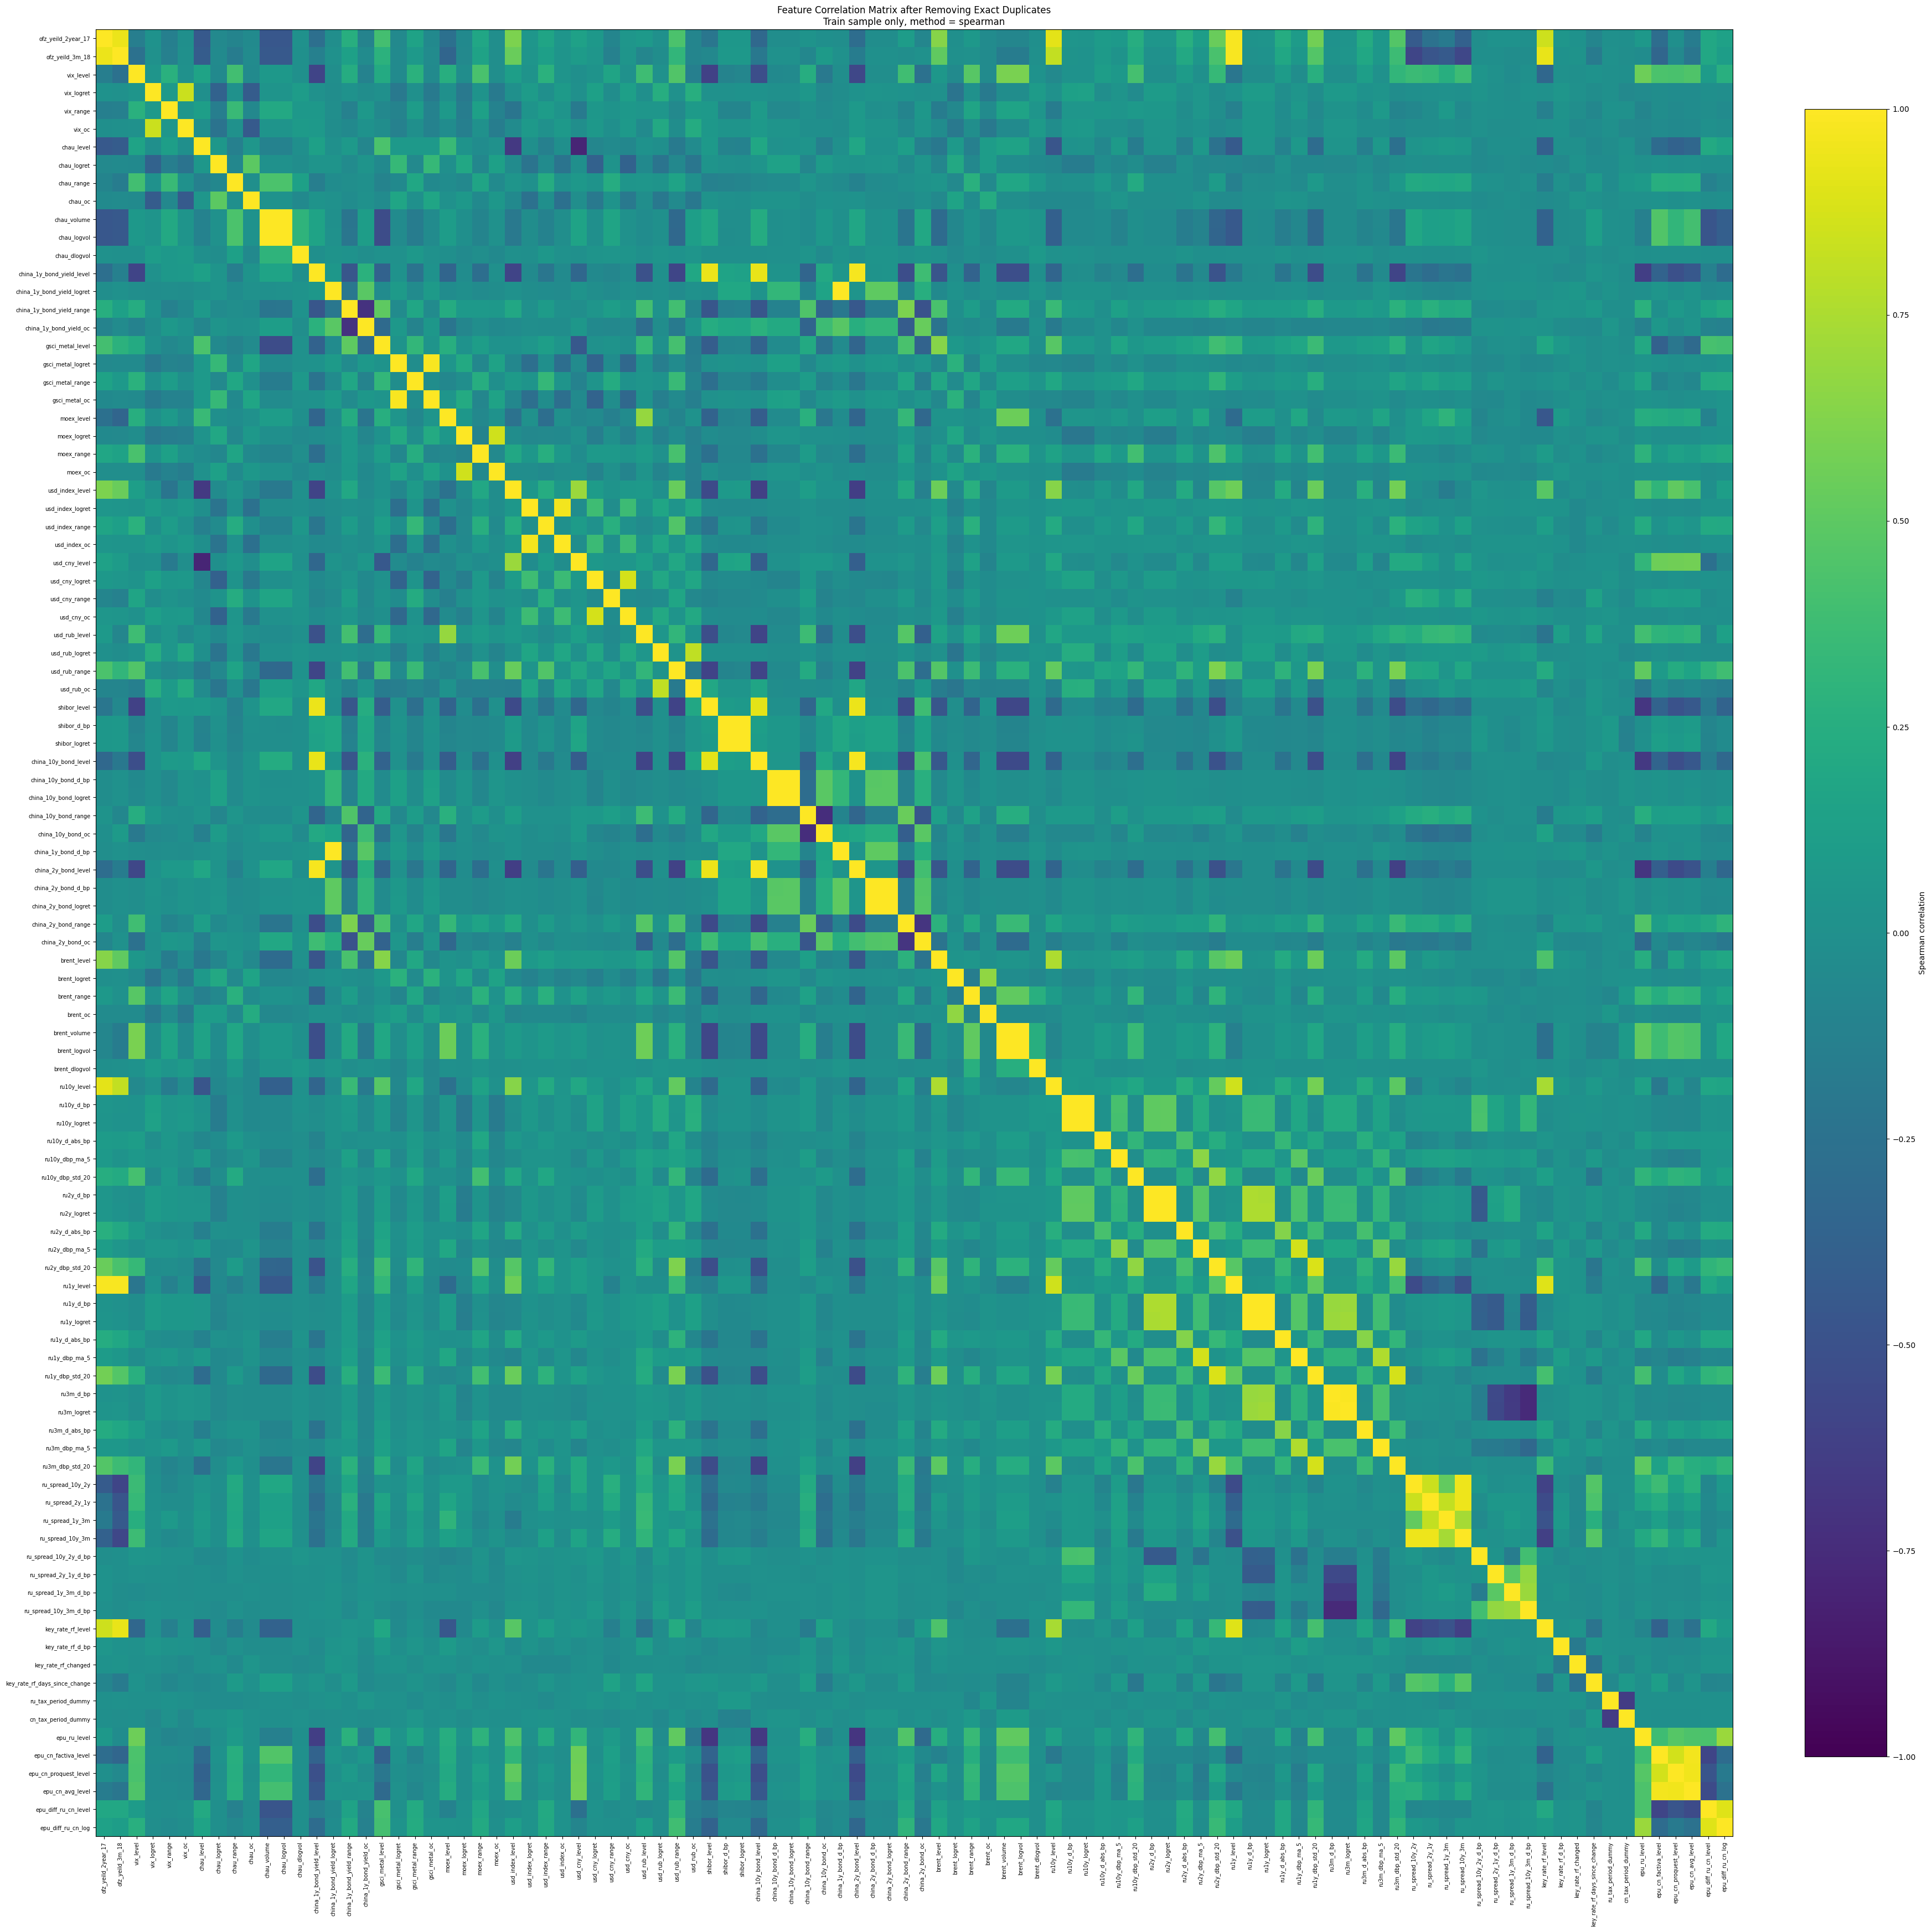


========== SAVED CORRELATION REPORTS ==========
- correlation_matrix_after_exact_duplicate_removal.png
- correlation_matrix_after_exact_duplicate_removal.xlsx
- top_correlated_pairs_after_exact_duplicate_removal.xlsx


In [ ]:
import matplotlib.pyplot as plt

CORR_METHOD = "spearman"
TOP_N_CORR_PAIRS = 50
SAVE_CORR_REPORTS = True

X_corr_train = X_train_3.copy()
X_corr_train = X_corr_train.replace([np.inf, -np.inf], np.nan)

corr_after_exact = (
    X_corr_train
    .corr(method=CORR_METHOD)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

abs_corr_after_exact = corr_after_exact.abs()

print("========== CORRELATION MATRIX AFTER EXACT DUPLICATE REMOVAL ==========")
print("Correlation method:", CORR_METHOD)
print("Number of features:", corr_after_exact.shape[0])
print("Matrix shape:", corr_after_exact.shape)

display(corr_after_exact.round(3))

upper_mask = np.triu(np.ones(abs_corr_after_exact.shape), k=1).astype(bool)

top_corr_pairs = (
    abs_corr_after_exact
    .where(upper_mask)
    .stack()
    .reset_index()
)

top_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

top_corr_pairs["correlation"] = top_corr_pairs.apply(
    lambda row: corr_after_exact.loc[row["feature_1"], row["feature_2"]],
    axis=1
)

top_corr_pairs = (
    top_corr_pairs
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"\n========== TOP {TOP_N_CORR_PAIRS} CORRELATED FEATURE PAIRS ==========")
display(top_corr_pairs.head(TOP_N_CORR_PAIRS))

n_features = corr_after_exact.shape[0]

plt.figure(figsize=(max(10, 0.35 * n_features), max(8, 0.35 * n_features)))

im = plt.imshow(
    corr_after_exact.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, fraction=0.046, pad=0.04, label=f"{CORR_METHOD.capitalize()} correlation")

plt.xticks(
    ticks=np.arange(n_features),
    labels=corr_after_exact.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=np.arange(n_features),
    labels=corr_after_exact.index,
    fontsize=7
)

plt.title(
    f"Feature Correlation Matrix after Removing Exact Duplicates\n"
    f"Train sample only, method = {CORR_METHOD}"
)

plt.tight_layout()

if SAVE_CORR_REPORTS:
    plt.savefig(
        "correlation_matrix_after_exact_duplicate_removal.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

if SAVE_CORR_REPORTS:
    corr_after_exact.to_excel("correlation_matrix_after_exact_duplicate_removal.xlsx")
    top_corr_pairs.to_excel("top_correlated_pairs_after_exact_duplicate_removal.xlsx", index=False)

    print("\n========== SAVED CORRELATION REPORTS ==========")
    print("- correlation_matrix_after_exact_duplicate_removal.png")
    print("- correlation_matrix_after_exact_duplicate_removal.xlsx")
    print("- top_correlated_pairs_after_exact_duplicate_removal.xlsx")

========== TOP-20 FEATURES BY CORRELATION WITH TARGET ==========


,feature,correlation_with_log_target,abs_correlation_with_log_target
0,usd_rub_range,0.554435,0.554435
1,ru2y_dbp_std_20,0.425168,0.425168
2,ru1y_dbp_std_20,0.394580,0.394580
3,ru3m_dbp_std_20,0.389423,0.389423
4,moex_range,0.345200,0.345200
5,usd_index_range,0.335504,0.335504
6,ru10y_dbp_std_20,0.320909,0.320909
7,vix_level,0.297632,0.297632
8,china_2y_bond_level,-0.290094,0.290094
9,ofz_yeild_2year_17,0.289649,0.289649



========== CORRELATION MATRIX AMONG TOP-20 TARGET-CORRELATED FEATURES ==========
Correlation method: spearman
Number of features: 20


,usd_rub_range,ru2y_dbp_std_20,ru1y_dbp_std_20,ru3m_dbp_std_20,moex_range,usd_index_range,ru10y_dbp_std_20,vix_level,china_2y_bond_level,ofz_yeild_2year_17,ru10y_level,usd_index_level,china_1y_bond_yield_level,shibor_level,china_10y_bond_level,ru1y_level,epu_ru_level,gsci_metal_range,ofz_yeild_3m_18,brent_range
usd_rub_range,1.000000,0.609000,0.601000,0.601000,0.414000,0.460000,0.322000,0.455000,-0.606000,0.430000,0.516000,0.537000,-0.581000,-0.600000,-0.590000,0.352000,0.511000,0.358000,0.313000,0.364000
ru2y_dbp_std_20,0.609000,1.000000,0.889000,0.693000,0.442000,0.322000,0.670000,0.338000,-0.505000,0.542000,0.526000,0.469000,-0.490000,-0.518000,-0.499000,0.480000,0.400000,0.305000,0.425000,0.303000
ru1y_dbp_std_20,0.601000,0.889000,1.000000,0.875000,0.395000,0.293000,0.542000,0.259000,-0.546000,0.573000,0.581000,0.540000,-0.535000,-0.501000,-0.525000,0.512000,0.406000,0.254000,0.462000,0.243000
ru3m_dbp_std_20,0.601000,0.693000,0.875000,1.000000,0.361000,0.275000,0.435000,0.316000,-0.624000,0.467000,0.492000,0.572000,-0.590000,-0.535000,-0.599000,0.410000,0.503000,0.168000,0.373000,0.246000
moex_range,0.414000,0.442000,0.395000,0.361000,1.000000,0.257000,0.398000,0.423000,-0.280000,0.187000,0.151000,0.200000,-0.280000,-0.264000,-0.255000,0.168000,0.296000,0.249000,0.153000,0.279000
usd_index_range,0.460000,0.322000,0.293000,0.275000,0.257000,1.000000,0.193000,0.278000,-0.225000,0.171000,0.224000,0.242000,-0.211000,-0.232000,-0.192000,0.141000,0.233000,0.330000,0.129000,0.270000
ru10y_dbp_std_20,0.322000,0.670000,0.542000,0.435000,0.398000,0.193000,1.000000,0.410000,-0.289000,0.248000,0.189000,0.202000,-0.279000,-0.298000,-0.270000,0.247000,0.310000,0.190000,0.222000,0.313000
vix_level,0.455000,0.338000,0.259000,0.316000,0.423000,0.278000,0.410000,1.000000,-0.574000,-0.142000,-0.060000,0.122000,-0.588000,-0.612000,-0.520000,-0.215000,0.555000,0.275000,-0.251000,0.480000
china_2y_bond_level,-0.606000,-0.505000,-0.546000,-0.624000,-0.280000,-0.225000,-0.289000,-0.574000,1.000000,-0.287000,-0.355000,-0.629000,0.974000,0.938000,0.970000,-0.204000,-0.691000,-0.210000,-0.160000,-0.358000
ofz_yeild_2year_17,0.430000,0.542000,0.573000,0.467000,0.187000,0.171000,0.248000,-0.142000,-0.287000,1.000000,0.919000,0.604000,-0.269000,-0.213000,-0.321000,0.982000,0.066000,0.150000,0.944000,0.065000



========== TOP CORRELATED PAIRS AMONG TOP-20 FEATURES ==========


,feature_1,feature_2,abs_correlation,correlation
0,ru1y_level,ofz_yeild_3m_18,0.982551,0.982551
1,ofz_yeild_2year_17,ru1y_level,0.982270,0.982270
2,china_2y_bond_level,china_1y_bond_yield_level,0.974251,0.974251
3,china_2y_bond_level,china_10y_bond_level,0.969679,0.969679
4,ofz_yeild_2year_17,ofz_yeild_3m_18,0.943759,0.943759
5,china_1y_bond_yield_level,shibor_level,0.943522,0.943522
6,china_2y_bond_level,shibor_level,0.938363,0.938363
7,china_1y_bond_yield_level,china_10y_bond_level,0.937412,0.937412
8,ofz_yeild_2year_17,ru10y_level,0.918502,0.918502
9,shibor_level,china_10y_bond_level,0.915578,0.915578


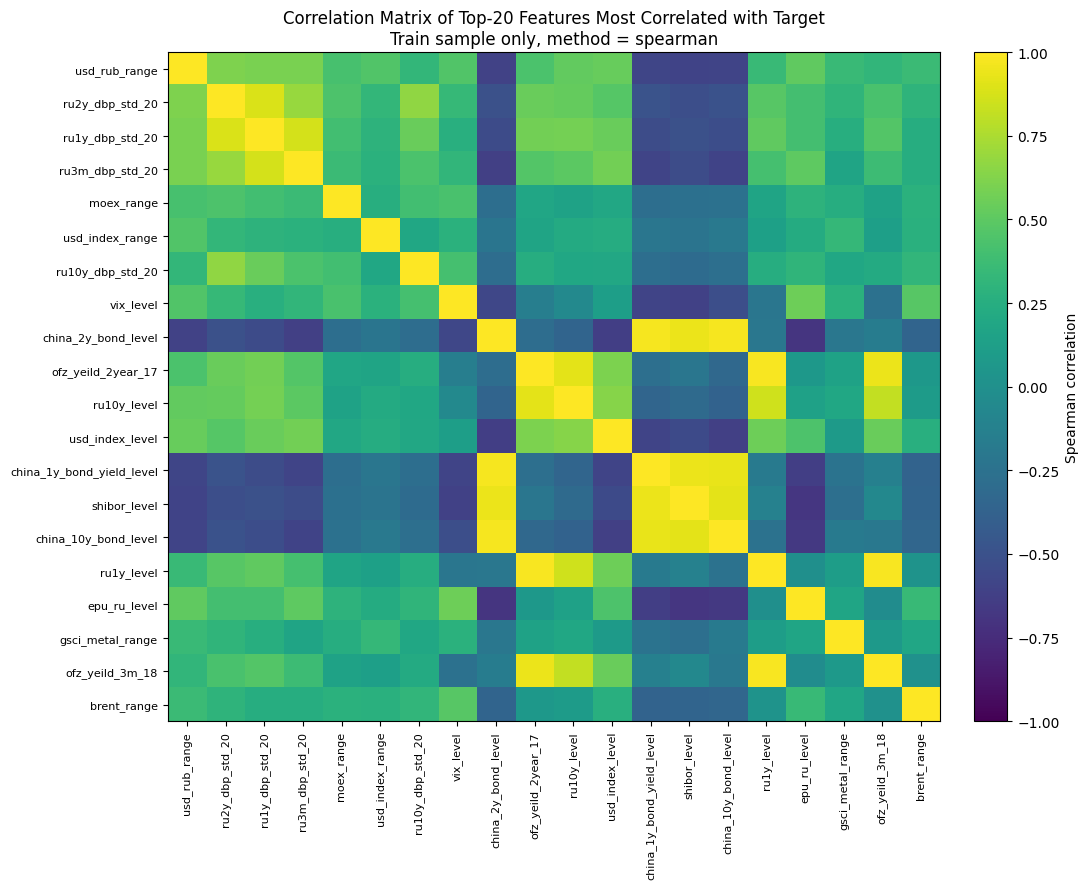


========== SAVED CORRELATION REPORTS ==========
- top20_target_correlated_features_matrix.png
- target_feature_correlations_after_duplicate_removal.xlsx
- top20_target_correlated_features_matrix.xlsx
- top20_target_correlated_feature_pairs.xlsx


In [ ]:

import matplotlib.pyplot as plt

CORR_METHOD = "spearman"
TOP_N_FEATURES_FOR_CORR_MATRIX = 20
SAVE_CORR_REPORTS = True

X_corr_train = X_train_3.copy()
X_corr_train = X_corr_train.replace([np.inf, -np.inf], np.nan)

y_corr_train = np.log(df_work.loc[train_mask, TARGET_COL].clip(lower=EPS))

target_corr = {}

for c in X_corr_train.columns:
    try:
        corr_value = X_corr_train[c].corr(y_corr_train, method=CORR_METHOD)
        if pd.isna(corr_value) or np.isinf(corr_value):
            corr_value = 0.0
        target_corr[c] = corr_value
    except Exception:
        target_corr[c] = 0.0

target_corr_table = (
    pd.DataFrame({
        "feature": list(target_corr.keys()),
        "correlation_with_log_target": list(target_corr.values())
    })
    .assign(abs_correlation_with_log_target=lambda x: x["correlation_with_log_target"].abs())
    .sort_values("abs_correlation_with_log_target", ascending=False)
    .reset_index(drop=True)
)

top20_corr_features = (
    target_corr_table
    .head(TOP_N_FEATURES_FOR_CORR_MATRIX)["feature"]
    .tolist()
)

print("========== TOP-20 FEATURES BY CORRELATION WITH TARGET ==========")
display(target_corr_table.head(TOP_N_FEATURES_FOR_CORR_MATRIX))


top20_feature_corr_matrix = (
    X_corr_train[top20_corr_features]
    .corr(method=CORR_METHOD)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

print("\n========== CORRELATION MATRIX AMONG TOP-20 TARGET-CORRELATED FEATURES ==========")
print("Correlation method:", CORR_METHOD)
print("Number of features:", len(top20_corr_features))

display(top20_feature_corr_matrix.round(3))

abs_top20_corr = top20_feature_corr_matrix.abs()
upper_mask = np.triu(np.ones(abs_top20_corr.shape), k=1).astype(bool)

top20_corr_pairs = (
    abs_top20_corr
    .where(upper_mask)
    .stack()
    .reset_index()
)

top20_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

top20_corr_pairs["correlation"] = top20_corr_pairs.apply(
    lambda row: top20_feature_corr_matrix.loc[row["feature_1"], row["feature_2"]],
    axis=1
)

top20_corr_pairs = (
    top20_corr_pairs
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

print("\n========== TOP CORRELATED PAIRS AMONG TOP-20 FEATURES ==========")
display(top20_corr_pairs.head(30))

n_features = top20_feature_corr_matrix.shape[0]

plt.figure(figsize=(11, 9))

im = plt.imshow(
    top20_feature_corr_matrix.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04,
    label=f"{CORR_METHOD.capitalize()} correlation"
)

plt.xticks(
    ticks=np.arange(n_features),
    labels=top20_feature_corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=np.arange(n_features),
    labels=top20_feature_corr_matrix.index,
    fontsize=8
)

plt.title(
    "Correlation Matrix of Top-20 Features Most Correlated with Target\n"
    f"Train sample only, method = {CORR_METHOD}"
)

plt.tight_layout()

if SAVE_CORR_REPORTS:
    plt.savefig(
        "top20_target_correlated_features_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()
if SAVE_CORR_REPORTS:
    target_corr_table.to_excel(
        "target_feature_correlations_after_duplicate_removal.xlsx",
        index=False
    )
    top20_feature_corr_matrix.to_excel(
        "top20_target_correlated_features_matrix.xlsx"
    )
    top20_corr_pairs.to_excel(
        "top20_target_correlated_feature_pairs.xlsx",
        index=False
    )

    print("\n========== SAVED CORRELATION REPORTS ==========")
    print("- top20_target_correlated_features_matrix.png")
    print("- target_feature_correlations_after_duplicate_removal.xlsx")
    print("- top20_target_correlated_features_matrix.xlsx")
    print("- top20_target_correlated_feature_pairs.xlsx")

Options

In [ ]:
import pandas as pd

In [ ]:


sample_2025 = cnyp_eur[
    (cnyp_eur["trade_date"] >= "2023-01-01") &
    (cnyp_eur["trade_date"] <= "2025-12-31")
].copy()

final_option_sample_number = len(sample_2025)
calls_number = (sample_2025["option_type"] == "C").sum()
puts_number = (sample_2025["option_type"] == "P").sum()

summary_2025 = pd.DataFrame({
    "Metric": [
        "Final option sample number",
        "Calls",
        "Puts"
    ],
    "Number": [
        final_option_sample_number,
        calls_number,
        puts_number
    ]
})

print("========== FINAL 2025 EUROPEAN CNYP OPTION SAMPLE ==========")
display(summary_2025)

print("\nDate range:")
print(sample_2025["trade_date"].min(), "->", sample_2025["trade_date"].max())

print("\nOption type shares:")
display(
    sample_2025["option_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Share, %")
    .reset_index()
    .rename(columns={"index": "Option type"})
)


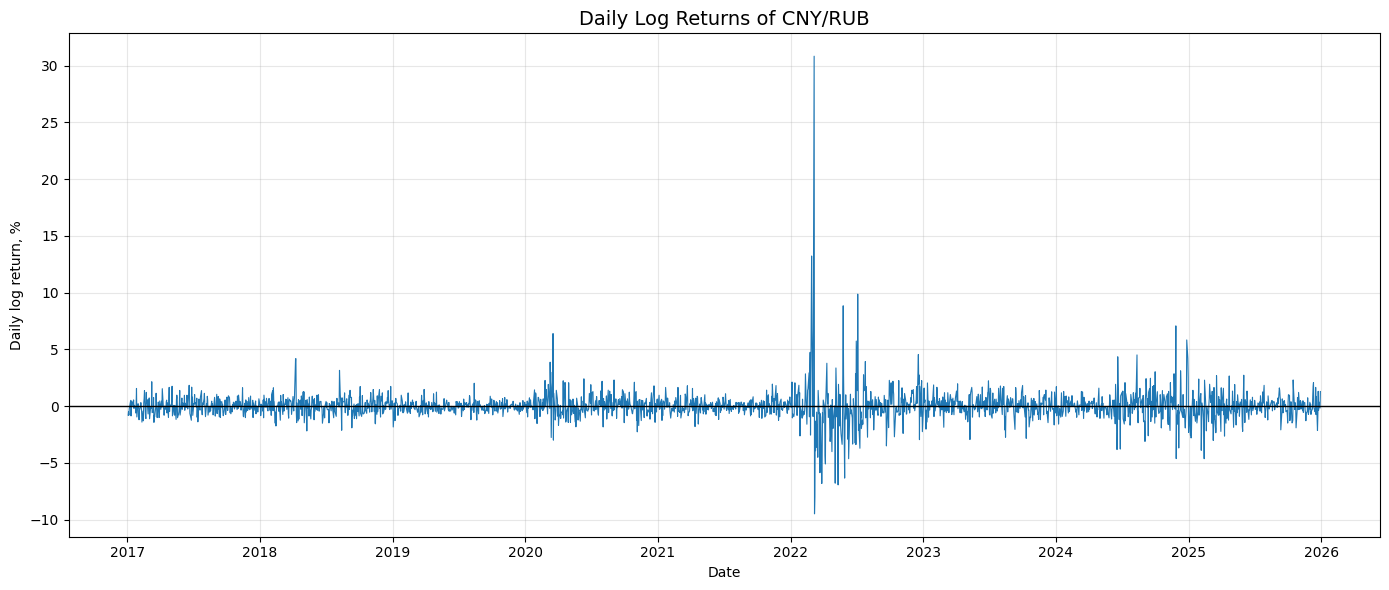

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df=pd.read_excel('/content/result_hope_8_march.xlsx')

df = df.copy()

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

plot_df = df.dropna(subset=["Date", "cnyrub_logret"]).copy()
plot_df["cnyrub_logret_pct"] = plot_df["cnyrub_logret"] * 100

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["Date"],
    plot_df["cnyrub_logret_pct"],
    linewidth=0.8
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Daily Log Returns of CNY/RUB", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Daily log return, %")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('/content/option_iv_smart_13_04.csv')
opt = df.copy()

opt["trade_date"] = pd.to_datetime(opt["trade_date"], dayfirst=True, errors="coerce")
opt["expiration_date"] = pd.to_datetime(opt["expiration_date"], dayfirst=True, errors="coerce")

num_cols = [
    "strike", "T_days", "T", "market_price", "spot", "spot_used",
    "settle_price", "volume", "open_interest"
]

for col in num_cols:
    if col in opt.columns:
        opt[col] = (
            opt[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        )
        opt[col] = pd.to_numeric(opt[col], errors="coerce")

cnyp_mask = pd.Series(False, index=opt.index)

for col in ["secid_raw", "secid_norm", "underlying_series"]:
    if col in opt.columns:
        cnyp_mask = cnyp_mask | opt[col].astype(str).str.upper().str.startswith("CNYP")

sample = opt[
    (opt["trade_date"].dt.year == 2025)
    & (opt["exercise_type"].astype(str).str.upper() == "E")
    & cnyp_mask
].copy()

print("Number of selected option observations:", len(sample))
print(sample[["trade_date", "secid_norm", "option_type", "exercise_type", "strike", "market_price"]].head())


sample["days_to_maturity"] = sample["T_days"]

fallback_dtm = (sample["expiration_date"] - sample["trade_date"]).dt.days
sample["days_to_maturity"] = sample["days_to_maturity"].fillna(fallback_dtm)

sample = sample[sample["days_to_maturity"] > 0].copy()


if "spot_used" in sample.columns and "spot" in sample.columns:
    sample["spot_for_moneyness"] = sample["spot_used"].fillna(sample["spot"])
elif "spot_used" in sample.columns:
    sample["spot_for_moneyness"] = sample["spot_used"]
else:
    sample["spot_for_moneyness"] = sample["spot"]

sample["moneyness"] = sample["strike"] / sample["spot_for_moneyness"]
sample["log_moneyness"] = np.log(sample["moneyness"])

sample = sample.replace([np.inf, -np.inf], np.nan)

print("Final sample size after maturity and moneyness calculation:", len(sample))

/tmp/ipykernel_3252/4030757437.py:12: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  opt["trade_date"] = pd.to_datetime(opt["trade_date"], dayfirst=True, errors="coerce")
/tmp/ipykernel_3252/4030757437.py:13: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  opt["expiration_date"] = pd.to_datetime(opt["expiration_date"], dayfirst=True, errors="coerce")


Number of selected option observations: 7683
      trade_date        secid_norm option_type exercise_type  strike  \
12909 2025-01-03  CNYP200225CE14.6           C             E    14.6   
12910 2025-01-03  CNYP200225CE14.2           C             E    14.2   
12911 2025-01-03    CNYP200225CE14           C             E    14.0   
12912 2025-01-03  CNYP200225CE13.8           C             E    13.8   
12913 2025-01-03  CNYP160125PE14.4           P             E    14.4   

       market_price  
12909         0.382  
12910         0.475  
12911         0.537  
12912         0.613  
12913         0.612  
Final sample size after maturity and moneyness calculation: 7683


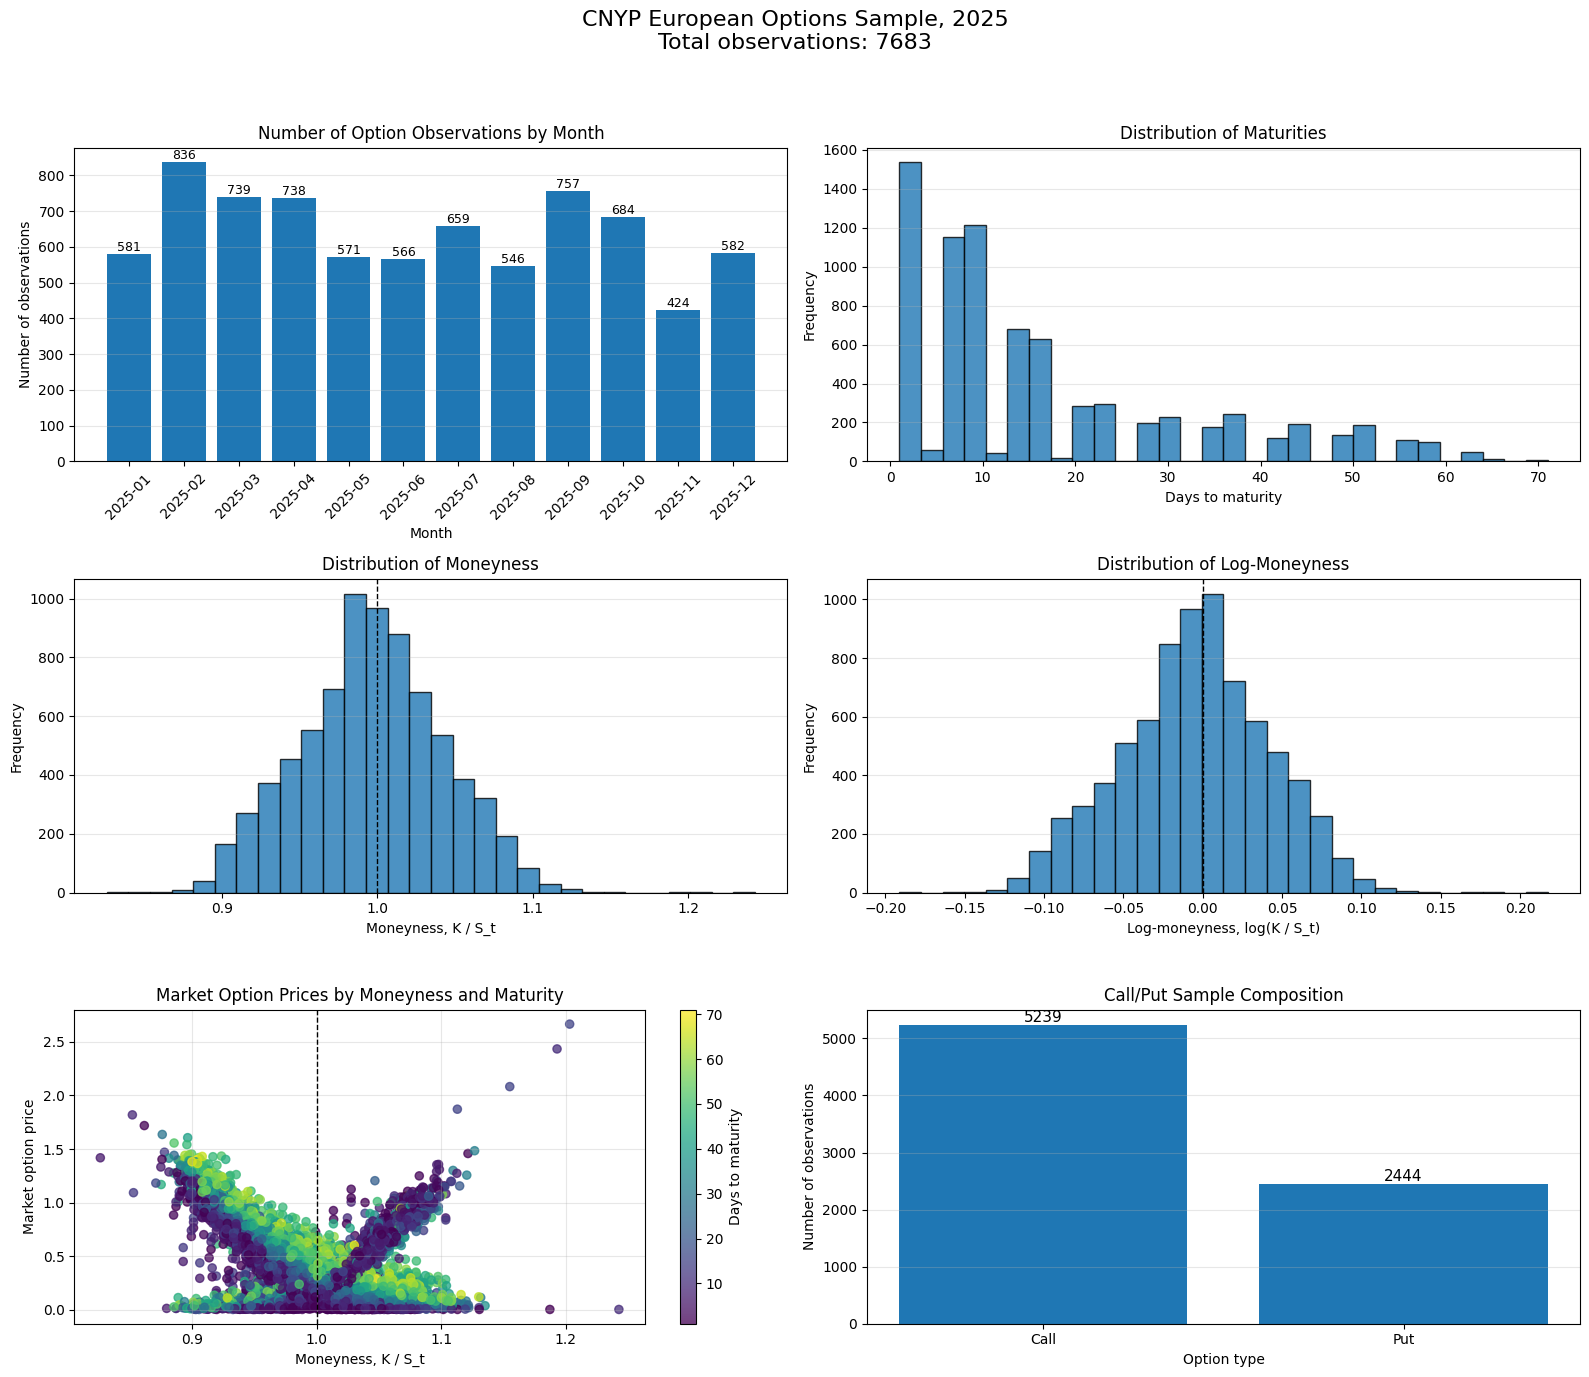

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

fig.suptitle(
    f"CNYP European Options Sample, 2025\nTotal observations: {len(sample)}",
    fontsize=16
)


month_index = pd.period_range("2025-01", "2025-12", freq="M")

monthly_counts = (
    sample["trade_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
    .reindex(month_index, fill_value=0)
)

axes[0, 0].bar(
    monthly_counts.index.astype(str),
    monthly_counts.values
)

axes[0, 0].set_title("Number of Option Observations by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Number of observations")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.3)

for i, value in enumerate(monthly_counts.values):
    axes[0, 0].text(i, value, str(value), ha="center", va="bottom", fontsize=9)

axes[0, 1].hist(
    sample["days_to_maturity"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[0, 1].set_title("Distribution of Maturities")
axes[0, 1].set_xlabel("Days to maturity")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(axis="y", alpha=0.3)


axes[1, 0].hist(
    sample["moneyness"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[1, 0].axvline(1, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title("Distribution of Moneyness")
axes[1, 0].set_xlabel("Moneyness, K / S_t")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].hist(
    sample["log_moneyness"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Distribution of Log-Moneyness")
axes[1, 1].set_xlabel("Log-moneyness, log(K / S_t)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(axis="y", alpha=0.3)

scatter_df = sample.dropna(
    subset=["moneyness", "market_price", "days_to_maturity"]
).copy()

sc = axes[2, 0].scatter(
    scatter_df["moneyness"],
    scatter_df["market_price"],
    c=scatter_df["days_to_maturity"],
    alpha=0.75,
    s=35
)

axes[2, 0].axvline(1, color="black", linestyle="--", linewidth=1)
axes[2, 0].set_title("Market Option Prices by Moneyness and Maturity")
axes[2, 0].set_xlabel("Moneyness, K / S_t")
axes[2, 0].set_ylabel("Market option price")
axes[2, 0].grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=axes[2, 0])
cbar.set_label("Days to maturity")

cp_counts = (
    sample["option_type"]
    .astype(str)
    .str.upper()
    .value_counts()
    .reindex(["C", "P"], fill_value=0)
)

axes[2, 1].bar(
    ["Call", "Put"],
    cp_counts.values
)

axes[2, 1].set_title("Call/Put Sample Composition")
axes[2, 1].set_xlabel("Option type")
axes[2, 1].set_ylabel("Number of observations")
axes[2, 1].grid(axis="y", alpha=0.3)

for i, value in enumerate(cp_counts.values):
    axes[2, 1].text(i, value, str(value), ha="center", va="bottom", fontsize=11)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
df

,trade_date,secid_raw,secid_norm,code_format,underlying_series,series_type,option_type,exercise_type,strike,expiration_date,...,iv_status,iv_model,rd_used,rf_used,spot_used,futures_used,iv,iv_pct,iv_found,iv_note
0,2022-06-20,CNY-9.22M150922CA10,CNY-9.22M150922CA10,long,CNY-9.22,M,C,A,10.00,2022-09-15,...,ok,FUTURES_AMERICAN_CRR,0.147790,0.019926,NaN,8.569524,0.602634,60.263443,True,american_futures_tree_with_synthetic_forward
1,2022-06-20,CNY-9.22M150922PA7,CNY-9.22M150922PA7,long,CNY-9.22,M,P,A,7.00,2022-09-15,...,ok,FUTURES_AMERICAN_CRR,0.147790,0.019926,NaN,8.569524,0.451150,45.115029,True,american_futures_tree_with_synthetic_forward
2,2022-06-22,CNY-9.22M150922CA9.75,CNY-9.22M150922CA9.75,long,CNY-9.22,M,C,A,9.75,2022-09-15,...,ok,FUTURES_AMERICAN_CRR,0.144924,0.019914,NaN,8.164611,0.767007,76.700672,True,american_futures_tree_with_synthetic_forward
3,2022-06-22,CNY-9.22M150922CA9.5,CNY-9.22M150922CA9.5,long,CNY-9.22,M,C,A,9.50,2022-09-15,...,ok,FUTURES_AMERICAN_CRR,0.144924,0.019914,NaN,8.164611,0.791105,79.110473,True,american_futures_tree_with_synthetic_forward
4,2022-06-22,CNY-9.22M150922CA8.75,CNY-9.22M150922CA8.75,long,CNY-9.22,M,C,A,8.75,2022-09-15,...,ok,FUTURES_AMERICAN_CRR,0.144924,0.019914,NaN,8.164611,0.907773,90.777339,True,american_futures_tree_with_synthetic_forward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29077,2025-12-30,CNY-3.26M150126PA10.75,CNY-3.26M150126PA10.75,long,CNY-3.26,M,P,A,10.75,2026-01-15,...,ok,FUTURES_AMERICAN_CRR,0.156739,0.018017,NaN,11.429502,0.175667,17.566726,True,american_futures_tree_with_synthetic_forward
29078,2025-12-30,CNY-3.26M150126PA11,CNY-3.26M150126PA11,long,CNY-3.26,M,P,A,11.00,2026-01-15,...,ok,FUTURES_AMERICAN_CRR,0.156739,0.018017,NaN,11.429502,0.145849,14.584942,True,american_futures_tree_with_synthetic_forward
29079,2025-12-30,CNY-3.26M150126PA11.25,CNY-3.26M150126PA11.25,long,CNY-3.26,M,P,A,11.25,2026-01-15,...,ok,FUTURES_AMERICAN_CRR,0.156739,0.018017,NaN,11.429502,0.124523,12.452288,True,american_futures_tree_with_synthetic_forward
29080,2025-12-30,CNYP080126PE11.4,CNYP080126PE11.4,compact,CNY,P,P,E,11.40,2026-01-08,...,ok,GK_EUR,0.150713,0.017130,11.36021,NaN,0.265467,26.546671,True,best_case


In [ ]:
df[df['']]

PeriodIndex(['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06',
             '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12'],
            dtype='period[M]')

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_excel('/content/result_hope_8_march.xlsx')
target_col = "target_RV_gk"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

target_stats = pd.DataFrame({
    "Mean": [df[target_col].mean()],
    "Std": [df[target_col].std()],
    "Min": [df[target_col].min()],
    "Median": [df[target_col].median()],
    "Max": [df[target_col].max()]
})

target_stats

,Mean,Std,Min,Median,Max
0,0.000183,0.001633,0.0,0.000041,0.045377


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_col = "target_RV_gk"
date_col = "Date"
data = df.copy()

data[date_col] = pd.to_datetime(data[date_col], dayfirst=True, errors="coerce")
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

data = data.dropna(subset=[date_col, target_col]).copy()
data = data.sort_values(date_col)
data["daily_volatility"] = np.sqrt(data[target_col])
data["daily_volatility_pct"] = data["daily_volatility"] * 100

data["annualized_volatility_pct"] = data["daily_volatility"] * np.sqrt(252) * 100

print("Observations:", len(data))
print(data[[target_col, "daily_volatility_pct", "annualized_volatility_pct"]].describe())

Observations: 2346
       target_RV_gk  daily_volatility_pct  annualized_volatility_pct
count   2346.000000           2346.000000                2346.000000
mean       0.000183              0.861736                  13.679631
std        0.001633              1.045170                  16.591558
min        0.000000              0.000000                   0.000000
25%        0.000020              0.443686                   7.043297
50%        0.000041              0.638044                  10.128642
75%        0.000091              0.953664                  15.138943
max        0.045377             21.301821                 338.155932


Stationariyt test

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss


date_col = "Date"
target_col = "target_RV_gk"

data = df.copy()

data[date_col] = pd.to_datetime(data[date_col], dayfirst=True, errors="coerce")
data[target_col] = pd.to_numeric(data[target_col], errors="coerce")

data = data.dropna(subset=[date_col, target_col]).copy()
data = data.sort_values(date_col)

data = data[
    (data[date_col].dt.year >= 2017) &
    (data[date_col].dt.year <= 2025)
].copy()

print("Date range:", data[date_col].min(), "->", data[date_col].max())
print("Observations:", len(data))

Date range: 2017-01-02 00:00:00 -> 2025-12-29 00:00:00
Observations: 2346


In [ ]:
def stationarity_tests(series, name="series"):
    x = pd.Series(series).dropna()
    x = x.replace([np.inf, -np.inf], np.nan).dropna()

    result = {
        "period": name,
        "n_obs": len(x),
        "mean": x.mean(),
        "std": x.std(),
        "adf_stat": np.nan,
        "adf_pvalue": np.nan,
        "kpss_stat": np.nan,
        "kpss_pvalue": np.nan,
        "conclusion": ""
    }

    if len(x) < 20 or x.nunique() <= 1:
        result["conclusion"] = "Not enough observations"
        return result

    try:
        adf_res = adfuller(x, autolag="AIC")
        result["adf_stat"] = adf_res[0]
        result["adf_pvalue"] = adf_res[1]
    except Exception as e:
        result["adf_pvalue"] = np.nan

    try:
        kpss_res = kpss(x, regression="c", nlags="auto")
        result["kpss_stat"] = kpss_res[0]
        result["kpss_pvalue"] = kpss_res[1]
    except Exception as e:
        result["kpss_pvalue"] = np.nan

    adf_stationary = result["adf_pvalue"] < 0.05
    kpss_stationary = result["kpss_pvalue"] > 0.05

    if adf_stationary and kpss_stationary:
        result["conclusion"] = "Stationary"
    elif adf_stationary and not kpss_stationary:
        result["conclusion"] = "ADF stationary, KPSS rejects stationarity"
    elif not adf_stationary and kpss_stationary:
        result["conclusion"] = "ADF non-stationary, KPSS stationary"
    else:
        result["conclusion"] = "Likely non-stationary"

    return result

In [ ]:
full_result = pd.DataFrame([
    stationarity_tests(data[target_col], "2017-2025")
])

full_result.round(6)

/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")


,period,n_obs,mean,std,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,conclusion
0,2017-2025,2346,0.000183,0.001633,-8.229268,0.0,0.214646,0.1,Stationary


In [ ]:
yearly_results = []

for year, g in data.groupby(data[date_col].dt.year):
    res = stationarity_tests(g[target_col], str(year))
    yearly_results.append(res)

yearly_results = pd.DataFrame(yearly_results)

yearly_results[
    [
        "period", "n_obs", "mean", "std",
        "adf_pvalue", "kpss_pvalue", "conclusion"
    ]
].round(6)

/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression

,period,n_obs,mean,std,adf_pvalue,kpss_pvalue,conclusion
0,2017,260,0.000049,0.000040,0.000000,0.010000,"ADF stationary, KPSS rejects stationarity"
1,2018,261,0.000055,0.000084,0.000000,0.100000,Stationary
2,2019,261,0.000021,0.000020,0.000000,0.100000,Stationary
3,2020,262,0.000078,0.000114,0.008555,0.100000,Stationary
4,2021,261,0.000033,0.000032,0.003304,0.046831,"ADF stationary, KPSS rejects stationarity"
5,2022,260,0.001028,0.004809,0.000158,0.100000,Stationary
6,2023,260,0.000089,0.000121,0.000000,0.100000,Stationary
7,2024,262,0.000176,0.000349,0.000234,0.010000,"ADF stationary, KPSS rejects stationarity"
8,2025,259,0.000124,0.000149,0.388891,0.010000,Likely non-stationary


In [ ]:
subperiods = {
    "2017-2019": ("2017-01-01", "2019-12-31"),
    "2020-2021": ("2020-01-01", "2021-12-31"),
    "2022": ("2022-01-01", "2022-12-31"),
    "2023-2025": ("2023-01-01", "2025-12-31"),
}

subperiod_results = []

for name, (start, end) in subperiods.items():
    g = data[
        (data[date_col] >= pd.to_datetime(start)) &
        (data[date_col] <= pd.to_datetime(end))
    ].copy()

    res = stationarity_tests(g[target_col], name)
    subperiod_results.append(res)

subperiod_results = pd.DataFrame(subperiod_results)

subperiod_results[
    [
        "period", "n_obs", "mean", "std",
        "adf_pvalue", "kpss_pvalue", "conclusion"
    ]
].round(6)

/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")
/tmp/ipykernel_5564/683778208.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(x, regression="c", nlags="auto")


,period,n_obs,mean,std,adf_pvalue,kpss_pvalue,conclusion
0,2017-2019,782,0.000042,0.000057,0.000000,0.010000,"ADF stationary, KPSS rejects stationarity"
1,2020-2021,523,0.000056,0.000087,0.003635,0.010000,"ADF stationary, KPSS rejects stationarity"
2,2022,260,0.001028,0.004809,0.000158,0.100000,Stationary
3,2023-2025,781,0.000130,0.000233,0.000786,0.021115,"ADF stationary, KPSS rejects stationarity"
